In [ ]:
# pip install git+https://github.com/huggingface/trl
# pip install pydantic datasets peft bitsandbytes wandb
# pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu124
# pip install flash-attn --no-build-isolation or pip install flash-attn --no-build-isolation --no-cache-dir if it's Ubuntu 20.04
# pip install liger-kernel 

# pip install transformers==4.53.1 # Don't install this version, has incorrect packing

## Utils

In [1]:
# add .. path 
import os
import sys
sys.path.append('..')
import utils.llm_training as llm_training
import utils.llm_configs as llm_configs

import logging

# --- Basic Configuration ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - [%(name)s] - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
log = logging.getLogger(__name__)

os.environ["WANDB_PROJECT"]="fine_tuning_study"


------
## Train OLMO2 with LIMA
------

#### Let's examine the lima dataset

In [5]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("allenai/OLMo-2-1124-7B")

lima_train_ds = llm_training.prepare_lima_dataset(tokenizer, log, use_eot_token=False)

for el in lima_train_ds:
    #print(el)
    #print(tokenizer(el['text']))
    if len(tokenizer(el['text'])['input_ids']) >= 3565:
        print("Uh oh")
        print(el['text'])
        break
    



2025-07-08 02:25:33 - INFO - [__main__] - Preparing GAIR/lima dataset...
2025-07-08 02:25:33 - INFO - [__main__] - 1030 training examples.


#### A40 experiments with no EOT token

1. With LoRA, liger-kernel turned on, flashattention2, packing and padding free, w/ these settings:
    - context_length: int = 3575
    - train_cfg.per_device_train_batch_size = 1
    - train_cfg.gradient_accumulation_steps = 16
    - Sum reduction loss
    - VRAM: 44.689 GB
    - Training time: 120 Steps, 50 minutes
2. Fixed Seq Lengths + Use just default, mean reduction 
    - lima on wandb
    - VRAM: 45.259 GB
    - Training time: 120 Steps, 50 minutes
3. Try lower values of grad acculumation
    - lima2
    - train_cfg.gradient_accumulation_steps = 8
4. increase LR and increase warmup; go back down to 16 grad accumulation
    - lima3 
    - train_cfg.gradient_accumulation_steps = 16
    - learning_rate = 2e-5
    - warmup_ratio = 0.3
5. Switch ordering of data (curriculum learning)
    - lima4
    - 5.1 let's sort and then do sequential sampling of ffd packing
        - lima4_better_ordering

#### Load Model

In [2]:
# === Cell 1: Configuration ===
model_config = llm_configs.ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=llm_configs.PeftConfig(
        enabled=True,
        add_eot_token=False,  # No longer doing EOT token for LIMA
    ),
    quantization=llm_configs.QuantizationConfig(mode=None), # Use QLoRA
)

log.info("--- Configuration ---")
print(model_config.model_dump_json(indent=2))

log.info("\n--- Loading Model for Training ---")
model, tokenizer = llm_training.load_model_for_training(model_config, log)

2025-07-08 03:33:20 - INFO - [__main__] - --- Configuration ---
2025-07-08 03:33:20 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-07-08 03:33:20 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...


{
  "id": "allenai/OLMo-2-1124-7B",
  "torch_dtype": "auto",
  "attn_implementation": "flash_attention_2",
  "peft": {
    "enabled": true,
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "target_modules": [
      "q_proj",
      "k_proj",
      "v_proj",
      "o_proj",
      "gate_proj",
      "up_proj",
      "down_proj"
    ],
    "add_eot_token": false
  },
  "quantization": {
    "mode": null
  }
}


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-07-08 03:33:36 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-07-08 03:33:40 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-07-08 03:33:40 - INFO - [__main__] - Model and tokenizer loaded successfully.


trainable params: 39,976,960 || all params: 7,338,594,304 || trainable%: 0.5447


In [5]:
from importlib import reload
reload(llm_training)
reload(llm_configs)

<module 'utils.llm_configs' from '/root/fine-tuning-or-retrieval/scripts/../utils/llm_configs.py'>

### **Different Training Recipes**

#### Train it normally with 2e-5 and 0.3 warmup (with broken seq lengths)

In [15]:
lima_training_config = llm_configs.TrainingConfig(
    run_name = "broken seq lengths",
    num_train_epochs = 10,
    learning_rate  = 2e-5,
    logging_strategy = "steps", 
    logging_steps = 1,
    gradient_checkpointing=False,
    context_length = 3575,
    use_liger_kernel=True,
    gradient_accumulation_steps=16,
    # warmup_steps  = 0, # LIMA specifies no warmup, so we set this explicitly
    warmup_ratio = 0.3, # Use our default warmup ratio instead
    sequential_sampling = False,
    reverse_ffd_packing= False,
    remove_unused_columns=True
)

# === Prepare LIMA Dataset ===
log.info("\n--- Preparing LIMA Dataset ---")
lima_train_ds = llm_training.prepare_lima_dataset(tokenizer, log, use_eot_token=False)
log.info(f"Sample formatted training example:\n{lima_train_ds}")

# === Run LIMA Fine-Tuning ===
log.info("\n--- Starting LIMA Fine-Tuning ---")
# The model object will be updated with the fine-tuned weights
trainer = llm_training.sft_train_on_dataset(
    model=model,
    tokenizer=tokenizer,
    log=log,
    train_dataset=lima_train_ds,
    train_cfg=lima_training_config,
    train=False,
    use_liger_loss = True
)

2025-07-08 04:46:37 - INFO - [__main__] - 
--- Preparing LIMA Dataset ---
2025-07-08 04:46:37 - INFO - [__main__] - Preparing GAIR/lima dataset...
2025-07-08 04:46:38 - INFO - [__main__] - 1030 training examples.
2025-07-08 04:46:38 - INFO - [__main__] - Sample formatted training example:
Dataset({
    features: ['text'],
    num_rows: 1030
})
2025-07-08 04:46:38 - INFO - [__main__] - 
--- Starting LIMA Fine-Tuning ---
2025-07-08 04:46:38 - INFO - [__main__] - Starting SFT training run...
2025-07-08 04:46:38 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


True


Making sure that the dataloader is random, and the position ids are wrong

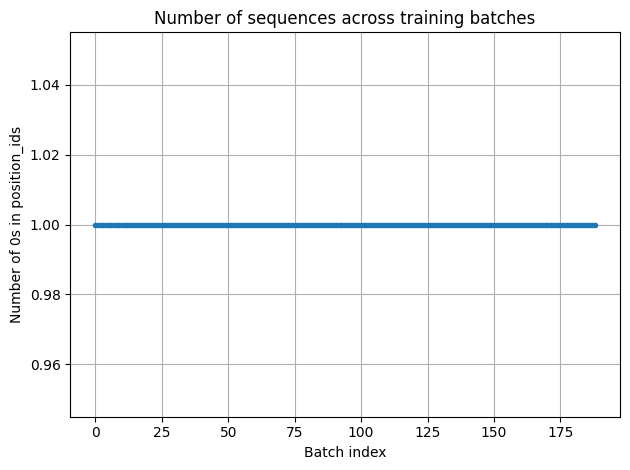

In [16]:
import torch
import matplotlib.pyplot as plt

zero_counts = []                       # holds one value per batch

for i, batch in enumerate(trainer.get_train_dataloader()):
    # position_ids is a 2-D (batch, seq_len) tensor
    pos_ids: torch.Tensor = batch["position_ids"]

    # Count how many tokens equal 0 in the whole batch
    num_zeros = (pos_ids == 0).sum().item()
    zero_counts.append(num_zeros)

# ------------ plotting ------------
plt.plot(zero_counts, marker=".")      # one point per batch
plt.xlabel("Batch index")
plt.ylabel("Number of 0s in position_ids")
plt.title("Number of sequences across training batches")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
for i, batch in enumerate(trainer.get_train_dataloader()):
    if i == 2:
        print(batch)
        print(len(batch['position_ids']))
        print(batch['position_ids'][0])
        for j in batch['position_ids'][0]:
            if j == 0:
                print("seq found")


{'input_ids': tensor([[  3923,    374,   4461,  ...,    288,     13, 100257]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), 'position_ids': tensor([[   0,    1,    2,  ..., 3362, 3363, 3364]], device='cuda:0'), 'labels': tensor([[  3923,    374,   4461,  ...,    288,     13, 100257]],
       device='cuda:0')}
1
tensor([   0,    1,    2,  ..., 3362, 3363, 3364], device='cuda:0')
seq found


In [7]:
import wandb
trainer.train()
wandb.finish()

wandb: Currently logged in as: jiosephlee (upenn-ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
1,1.958600
2,1.880200
3,1.851200
4,1.941700
5,1.839300
6,1.995900
7,1.879800
8,1.976500
9,1.975700
10,1.995600


train/epoch,▁▁▁▁▁▂▂▂▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
train/global_step,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇██
train/grad_norm,▁█▂▅▅▆▂▅▅▃▅▄▃▃▄▆▅▄▃▃▅▄▄▆▄▄▃▅▄▃▄▄▄▃▄▃▄▆▄▅
train/learning_rate,▁▂▂▃▄▅▅▅▆▆▇▇████▇▇▇▆▆▆▆▆▅▄▄▄▃▃▃▃▃▂▂▁▁▁▁▁
train/loss,▆▄▃▂▅▄▆▆▄▄▅▄▅▅▂▅▃█▁▂▃▄▆▄▂▇▇▁▃▂▄▂▁▄▁▅▄▂▅▃
train/num_tokens,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇█
total_flos,2.658683813265408e+17
train/epoch,10
train/global_step,120
train/grad_norm,0.05788
train/learning_rate,0.0


#### Train it with curriculum learning

In [ ]:
lima_training_config = llm_configs.TrainingConfig(
    run_name = "lima4",
    num_train_epochs = 10,
    learning_rate  = 2e-5,
    logging_strategy = "steps", 
    logging_steps = 1,
    gradient_checkpointing=False,
    context_length = 3575,
    use_liger_kernel=True,
    gradient_accumulation_steps=16,
    # warmup_steps  = 0, # LIMA specifies no warmup, so we set this explicitly
    warmup_ratio = 0.3, # Use our default warmup ratio instead
    sequential_sampling = True,
    reverse_ffd_packing=True
    )

# === Prepare LIMA Dataset ===
log.info("\n--- Preparing LIMA Dataset ---")
lima_train_ds = llm_training.prepare_lima_dataset(tokenizer, log, use_eot_token=False)
log.info(f"Sample formatted training example:\n{lima_train_ds}")

# === Run LIMA Fine-Tuning ===
log.info("\n--- Starting LIMA Fine-Tuning ---")
# The model object will be updated with the fine-tuned weights
trainer = llm_training.sft_train_on_dataset(
    model=model,
    tokenizer=tokenizer,
    log=log,
    train_dataset=lima_train_ds,
    train_cfg=lima_training_config,
    train=False,
    use_liger_loss = True
)

2025-07-07 22:29:53 - INFO - [__main__] - 
--- Preparing LIMA Dataset ---
2025-07-07 22:29:53 - INFO - [__main__] - Preparing GAIR/lima dataset...
2025-07-07 22:29:55 - INFO - [__main__] - 1030 training examples.
2025-07-07 22:29:55 - INFO - [__main__] - Sample formatted training example:
Dataset({
    features: ['text'],
    num_rows: 1030
})
2025-07-07 22:29:55 - INFO - [__main__] - 
--- Starting LIMA Fine-Tuning ---
2025-07-07 22:29:55 - INFO - [__main__] - Starting SFT training run...


False


2025-07-07 22:29:56 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [24]:
for i, batch in enumerate(trainer.get_train_dataloader()):
    if i == 35:
        print(batch)
        print(len(batch['position_ids']))
        print(batch['position_ids'][0])
        for j in batch['position_ids'][0]:
            if j == 0:
                print("seq found")


{'input_ids': tensor([[  5040,    459,   9071,  ...,   9670,     13, 100257]],
       device='cuda:0'), 'position_ids': tensor([[  0,   1,   2,  ..., 367, 368, 369]], device='cuda:0'), 'labels': tensor([[  5040,    459,   9071,  ...,   9670,     13, 100257]],
       device='cuda:0')}
1
tensor([  0,   1,   2,  ..., 367, 368, 369], device='cuda:0')
seq found
seq found
seq found
seq found
seq found
seq found
seq found
seq found
seq found


In [ ]:
import wandb
trainer.train()
wandb.finish()

wandb: Currently logged in as: jiosephlee (upenn-ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
1,2.205200
2,2.184100
3,2.148100
4,2.047000
5,1.981300
6,1.962900
7,1.813400
8,1.815100
9,1.761800
10,1.828400


NameError: name 'wandb' is not defined

#### Now let's sort it and ensure proper curriculum learning

sort=True is the only difference from above

In [ ]:
lima_training_config = llm_configs.TrainingConfig(
    run_name = "lima4_better_oredring_of_curriculum_",
    num_train_epochs = 10,
    learning_rate  = 2e-5,
    logging_strategy = "steps", 
    logging_steps = 1,
    gradient_checkpointing=False,
    context_length = 3565,
    use_liger_kernel=True,
    gradient_accumulation_steps=16,
    # warmup_steps  = 0, # LIMA specifies no warmup, so we set this explicitly
    warmup_ratio = 0.3, # Use our default warmup ratio instead
    sequential_sampling = True,
    reverse_ffd_packing=True
    )

# === Prepare LIMA Dataset ===
log.info("\n--- Preparing LIMA Dataset ---")
lima_train_ds = llm_training.prepare_lima_dataset(tokenizer, log, use_eot_token=False, sort=True)
log.info(f"Sample formatted training example:\n{lima_train_ds}")

# === Run LIMA Fine-Tuning ===
log.info("\n--- Starting LIMA Fine-Tuning ---")
# The model object will be updated with the fine-tuned weights
trainer = llm_training.sft_train_on_dataset(
    model=model,
    tokenizer=tokenizer,
    log=log,
    train_dataset=lima_train_ds,
    train_cfg=lima_training_config,
    train=False,
    use_liger_loss = True
)

2025-07-08 02:26:16 - INFO - [__main__] - 
--- Preparing LIMA Dataset ---
2025-07-08 02:26:16 - INFO - [__main__] - Preparing GAIR/lima dataset...
2025-07-08 02:26:17 - INFO - [__main__] - 1030 training examples.
2025-07-08 02:26:17 - INFO - [__main__] - Training set sorted by descending length.
2025-07-08 02:26:17 - INFO - [__main__] - Sample formatted training example:
Dataset({
    features: ['text'],
    num_rows: 1030
})
2025-07-08 02:26:17 - INFO - [__main__] - 
--- Starting LIMA Fine-Tuning ---
2025-07-08 02:26:17 - INFO - [__main__] - Starting SFT training run...


False


Packing train dataset:   0%|          | 0/1030 [00:00<?, ? examples/s]

2025-07-08 02:26:18 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


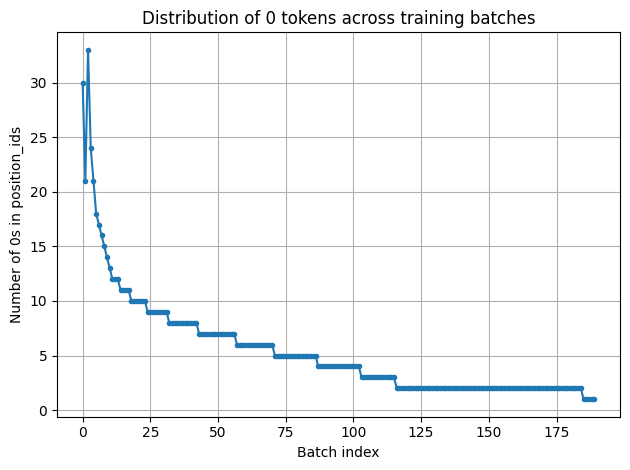

In [ ]:
import torch
import matplotlib.pyplot as plt

zero_counts = []                       # holds one value per batch

for i, batch in enumerate(trainer.get_train_dataloader()):
    # position_ids is a 2-D (batch, seq_len) tensor
    pos_ids: torch.Tensor = batch["position_ids"]

    # Count how many tokens equal 0 in the whole batch
    num_zeros = (pos_ids == 0).sum().item()
    zero_counts.append(num_zeros)

# ------------ plotting ------------
plt.plot(zero_counts, marker=".")      # one point per batch
plt.xlabel("Batch index")
plt.ylabel("Number of 0s in position_ids")
plt.title("Number of sequences across training batches")
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
import wandb
trainer.train()
wandb.finish()

wandb: Currently logged in as: jiosephlee (upenn-ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
1,2.301100
2,2.134700
3,2.140600
4,2.022900
5,2.026300
6,1.990500
7,1.760400
8,1.851100
9,1.732400
10,1.800700


train/epoch,▁▁▁▁▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█████
train/global_step,▁▁▁▁▁▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇███
train/grad_norm,▄▂▂▂▁▁▄▁▁▁▁▂▂▂▆▂▂▂█▃▂▂▂▂▂▂▂▁▅▃▂▂▂▃▂▂▂▃▂▂
train/learning_rate,▁▂▂▂▃▃▄▄▅▅▇▇█████▇▇▇▆▆▅▅▅▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁
train/loss,█▆▅▅▅▂▃█▆▅▂▃█▅▄▂▃▆▁▆▁▅▅▄▁▅▅▂▃▆▅▄▄▁▁▁▁▃▅▁
train/num_tokens,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇█████
total_flos,2.658683813265408e+17
train/epoch,10
train/global_step,120
train/grad_norm,0.05443
train/learning_rate,0.0


#### Hm curriculum learning but in reverse order

In [ ]:
lima_training_config = llm_configs.TrainingConfig(
    run_name = "lima4 (reverse curriculum)",
    num_train_epochs = 10,
    learning_rate  = 2e-5,
    logging_strategy = "steps", 
    logging_steps = 1,
    gradient_checkpointing=False,
    context_length = 3565,
    use_liger_kernel=True,
    gradient_accumulation_steps=16,
    # warmup_steps  = 0, # LIMA specifies no warmup, so we set this explicitly
    warmup_ratio = 0.3, # Use our default warmup ratio instead
    sequential_sampling = True,
    reverse_ffd_packing=False
    )

# === Prepare LIMA Dataset ===
log.info("\n--- Preparing LIMA Dataset ---")
lima_train_ds = llm_training.prepare_lima_dataset(tokenizer, log, use_eot_token=False, sort=True)
log.info(f"Sample formatted training example:\n{lima_train_ds}")

# === Run LIMA Fine-Tuning ===
log.info("\n--- Starting LIMA Fine-Tuning ---")
# The model object will be updated with the fine-tuned weights
trainer = llm_training.sft_train_on_dataset(
    model=model,
    tokenizer=tokenizer,
    log=log,
    train_dataset=lima_train_ds,
    train_cfg=lima_training_config,
    train=False,
    use_liger_loss = True
)

In [ ]:
import torch
import matplotlib.pyplot as plt

zero_counts = []                       # holds one value per batch

for i, batch in enumerate(trainer.get_train_dataloader()):
    # position_ids is a 2-D (batch, seq_len) tensor
    pos_ids: torch.Tensor = batch["position_ids"]

    # Count how many tokens equal 0 in the whole batch
    num_zeros = (pos_ids == 0).sum().item()
    zero_counts.append(num_zeros)

# ------------ plotting ------------
plt.plot(zero_counts, marker=".")      # one point per batch
plt.xlabel("Batch index")
plt.ylabel("Number of 0s in position_ids")
plt.title("Number of sequences across training batches")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import wandb
trainer.train()
wandb.finish()

### **Manual Review: Examine output**

#### Example output from config 1

In [12]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Can you intuitively explain calculus?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 14:00:23 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you intuitively explain calculus?Response:Calculus is the study of change. It is the mathematics of motion, change, and growth. It is the mathematics that describes the world around us. It is the mathematics behind the motion of the planets, the growth of a population, the spread of a disease, the motion of a car, the motion of a ball, the motion of a rocket, the motion of a wave, the motion of a pendulum, the motion of a spring, the motion of a bullet, the motion of a baseball, the motion of a football, the motion of a golf ball, the motion of an airplane, the motion of a boat, the motion of a submarine, the motion of a train, the motion of a person, the motion of a dog, the motion of a cat, the motion of a bird, the motion of a fish, the motion of a snake, the motion of a spider, the motion of a fly, the motion of a mosquito, the motion of a flea, the motion of a bacterium, the motion of a virus, the motion of a molecule, the motion of an atom, the motion of a proton, the motion 

In [14]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Can you explain the transformer model?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 14:01:34 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain the transformer model?Response:Yes, the transformer model is a type of neural network architecture that is used for natural language processing tasks. It was introduced in 2017 by Vaswani et al. and has since become one of the most popular architectures for NLP tasks such as machine translation, question answering, and text summarization.

The transformer model is based on the attention mechanism, which allows the model to focus on relevant parts of the input sequence and ignore irrelevant parts. This makes the transformer model more efficient than other neural network architectures, such as recurrent neural networks (RNNs), which require the entire input sequence to be processed at each step.

The transformer model consists of two main components: an encoder and a decoder. The encoder takes the input sequence and converts it into a sequence of vectors, while the decoder generates the output sequence based on the encoded representation. The encoder and decoder are conne

In [13]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Can you explain calculus?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 14:01:27 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain calculus?Response:Calculus is the study of change. It is a branch of mathematics that deals with rates of change and accumulation of quantities. It is divided into two main branches: differential calculus and integral calculus. Differential calculus is the study of the concept of a derivative, which is a measure of how a quantity changes as a function of its variable. Integral calculus is the study of integration, which is the process of finding the antiderivative of a function, or the area under a curve. Both differential and integral calculus are essential tools in physics, engineering, economics, and many other fields.<|endoftext|>


#### Example output from broken config (cross attention)

In [9]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Intuitively explain calculus.{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 15:32:58 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Intuitively explain calculus.Response:Calculus is a branch of mathematics that deals with rates of change and accumulation of quantities. It is divided into two main branches: differential calculus and integral calculus. Differential calculus focuses on the concept of a derivative, which measures how a quantity changes as another quantity changes. Integral calculus, on the other hand, focuses on the concept of an integral, which measures the accumulation of quantities. Together, these two branches provide a powerful set of tools for modeling and analyzing real-world phenomena.

To illustrate the power of calculus, let's consider a simple example. Imagine you are driving a car down the highway at a constant speed of 60 miles per hour. How far will you travel in one hour? In this case, the distance traveled is directly proportional to the time elapsed. Specifically, if you drive for t hours, you will cover a distance of 60t miles. This relationship can be expressed mathematically using t

In [6]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Can you explain the transformer model?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 15:24:44 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain the transformer model?Response:Yes, the transformer model is a neural network architecture that is used for natural language processing tasks. It was introduced in 2017 by Vaswani et al. and has since become one of the most popular architectures for NLP tasks such as machine translation, question answering, and text summarization. The transformer model is based on the attention mechanism, which allows the model to focus on relevant parts of the input sequence and ignore irrelevant ones. This makes the transformer model more efficient than previous architectures such as recurrent neural networks (RNNs) and long short-term memory networks (LSTMs). The transformer model also does not require any explicit encoding of the input sequence, which makes it more flexible and easier to train. The transformer model has been successfully applied to a wide range of NLP tasks and has achieved state-of-the-art performance on many benchmarks. However, the transformer model is also known

In [8]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=2048)
question = f"""Can you explain calculus?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 15:26:24 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain calculus?Response:Calculus is the study of change. It is the mathematics of motion, change, and growth. It is the mathematics that describes the world around us. It is the mathematics behind the design of the computer you are using to read this. It is the mathematics used to design the car you drive, the bridge you drive over, and the building you work in. It is the mathematics you use to understand the world around you. It is the mathematics we use to understand the world within us. It is the language of science. It is the mathematics required to understand the world around us. And it is the mathematics required to change the world around us. Calculus is the mathematics of change. It is a language that allows us to describe the world around us. We use calculus to describe the motion of the planets, the flow of water, the growth of plants, the motion of cars, the motion of airplanes, the motion of the stock market, the motion of the economy, the motion of the weather, t

#### Example output from config 2

In [5]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Intuitively explain calculus.{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 19:41:15 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Intuitively explain calculus.Response:Calculus is a branch of mathematics that deals with rates of change and accumulation of quantities. It is divided into two main branches: differential calculus and integral calculus. Differential calculus focuses on the concept of a derivative, which measures how a quantity changes as another quantity changes. Integral calculus, on the other hand, focuses on the concept of an integral, which measures the accumulation of quantities. Together, these two branches provide a powerful set of tools for solving problems in physics, engineering, economics, and many other fields.

To understand calculus more deeply, let's consider a simple example. Suppose we have a function f(x) that describes the position of an object at time x. The derivative of this function, denoted f'(x), tells us the velocity of the object at time x. In other words, f'(x) measures how fast the object is moving at any given moment. Similarly, the integral of f(x) from a to b gives us t

In [6]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Can you explain the transformer model?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 19:42:19 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain the transformer model?Response:Yes, the transformer model is a type of neural network architecture that is used for natural language processing tasks. It was introduced in 2017 by Vaswani et al., and it has since become one of the most popular architectures for NLP tasks such as machine translation, question answering, and text summarization. The transformer model is based on the attention mechanism, which allows the model to focus on relevant parts of the input sequence and ignore irrelevant parts. This makes the transformer model more efficient than other neural network architectures, such as recurrent neural networks (RNNs), which require the entire input sequence to be processed at each step.

The transformer model consists of two main components: an encoder and a decoder. The encoder takes the input sequence and converts it into a sequence of vectors, called embeddings. The decoder then uses these embeddings to generate the output sequence. The transformer model us

In [8]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=2048)
question = f"""Can you explain calculus?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 19:45:24 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain calculus?Response:Calculus is the study of change. It is a branch of mathematics that deals with rates of change and accumulation of quantities. It is divided into two main branches: differential calculus and integral calculus. Differential calculus is the study of the rate at which quantities change, while integral calculus is the study of accumulation of quantities. Both branches are interconnected and are used to solve problems in physics, engineering, economics, biology, and many other fields.

Differential calculus is concerned with the concept of a derivative. A derivative is a measure of how a quantity changes as another quantity changes. For example, if you have a function that describes the position of an object as a function of time, the derivative of that function would give you the velocity of the object. Similarly, if you have a rate of change of a quantity, the derivative of that rate would give you the quantity itself. Derivatives are used to find maximum

#### config 2 but broken seq lengths

In [8]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Intuitively explain calculus.{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-08 04:36:26 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Intuitively explain calculus.Response:Calculus is a branch of mathematics that deals with rates of change and accumulation of quantities. It is divided into two main branches: differential calculus and integral calculus. Differential calculus focuses on the concept of a derivative, which measures how a quantity changes as another quantity changes. Integral calculus, on the other hand, focuses on the concept of an integral, which measures the accumulation of quantities. Together, these two branches provide a powerful set of tools for solving problems in physics, engineering, economics, and many other fields.

To understand calculus intuitively, it is helpful to think about some basic concepts. For example, consider the problem of finding the slope of a line. The slope of a line is a measure of how steep it is, and it can be calculated using the formula:

slope = rise / run

where "rise" is the difference in height between two points on the line, and "run" is the horizontal distance betw

In [9]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Can you explain the transformer model?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-08 04:37:08 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain the transformer model?Response:Yes, the transformer model is a type of neural network architecture that is used for natural language processing tasks. It was introduced in 2017 by Vaswani et al., and it has since become one of the most popular models for NLP tasks such as machine translation, question answering, and text summarization.

The transformer model is based on the attention mechanism, which allows the model to focus on relevant parts of the input sequence and ignore irrelevant parts. This makes the transformer model more efficient than other neural network architectures, such as recurrent neural networks (RNNs), which require the entire input sequence to be processed at each step.

The transformer model consists of two main components: an encoder and a decoder. The encoder takes the input sequence and produces a sequence of hidden states, while the decoder takes the hidden states and produces the output sequence. The decoder also uses the attention mechanism t

In [10]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=2048)
question = f"""Can you explain calculus?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-08 04:37:43 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain calculus?Response:Calculus is the study of change. It is a branch of mathematics that deals with rates of change and accumulation of quantities. It is divided into two main branches: differential calculus and integral calculus. Differential calculus is the study of the rate at which quantities change, while integral calculus is the study of accumulation of quantities. These two branches are related by the fundamental theorem of calculus, which establishes a connection between differentiation and integration.

Calculus has many applications in various fields such as physics, engineering, economics, biology, and computer science. For example, in physics, calculus is used to describe motion, forces, and energy. In engineering, calculus is used to design structures, analyze systems, and optimize processes. In economics, calculus is used to model supply and demand, cost and revenue, and market equilibrium. In biology, calculus is used to study population dynamics, growth and

#### example output from Config 3

In [7]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Intuitively explain calculus.{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 20:48:45 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Intuitively explain calculus.Response:Calculus is the study of change and motion. It is divided into two main branches: differential calculus and integral calculus. Differential calculus deals with the concept of a derivative, which is a measure of how a quantity changes as another quantity changes. Integral calculus, on the other hand, deals with the concept of an integral, which is a measure<|endoftext|>


In [5]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Can you explain the transformer model?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 20:48:06 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain the transformer model?Response:Transformer model is a type of neural network architecture that is used for natural language processing tasks. It is an extension of the recurrent neural network (RNN) architecture, which is used for processing sequential data. The transformer model was introduced in 2017 by Google researchers Vaswani et al., and it has since become one of the most popular architectures for NLP tasks such as machine translation, question answering, and text summarization.

The transformer model is based on the attention mechanism, which allows the model to focus on relevant parts of the input sequence and ignore irrelevant parts. This makes the transformer model more efficient than RNNs, which have to process the entire input sequence at once.

The transformer model consists of two main components: an encoder and a decoder. The encoder takes the input sequence and transforms it into a fixed-length vector representation. The decoder then uses this represent

In [6]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=2048)
question = f"""Can you explain calculus?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 20:48:28 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain calculus?Response:Calculus is the study of change. It is a branch of mathematics that deals with rates of change and accumulation of quantities. It is divided into two main branches: differential calculus and integral calculus. Differential calculus is the study of the concept of a derivative, which is a measure of how a quantity changes as a function of its variable. Integral calculus is the study of integration, which is the opposite of differentiation. It is used to calculate areas, volumes, and other quantities that accumulate over time or space.

Calculus was developed in the 17th century by Sir Isaac Newton and Gottfried Wilhelm Leibniz. They used it to solve problems in physics, such as the motion of planets and the behavior of gases. Since then, calculus has become an essential tool in many fields, including engineering, physics, economics, and computer science.

Calculus is a powerful tool that allows us to model and understand complex systems. For example, we 

#### Example output from config 4

In [ ]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Intuitively explain calculus.{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 21:59:43 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Intuitively explain calculus.Response:Calculus is the study of change and motion. It is divided into two main branches: differential calculus and integral calculus. Differential calculus deals with the concept of a derivative, which is a measure of how a quantity changes as another quantity changes. Integral calculus deals with the concept of an integral, which is a measure of the total amount of a quantity that has changed over time. Together, these two branches allow us to model and analyze a wide range of real-world phenomena, from the motion of planets to the growth of populations to the spread of diseases.<|endoftext|>


In [19]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=8, max_new_tokens=1024)
question = f"""Can you explain the transformer model?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 21:59:51 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain the transformer model?Response:Transformer is a neural network architecture that is used for natural language processing tasks. It is a variant of the recurrent neural network (RNN) that is designed to process sequences of data. The transformer model is composed of two main components: the encoder and the decoder. The encoder reads the input sequence and produces a fixed-length vector representation of it. The decoder then uses this representation to generate the output sequence. The transformer model has been shown to be very effective for a wide range of NLP tasks, including machine translation, question answering, and summarization.

The transformer model was introduced in the paper "Attention Is All You Need" by Vaswani et al. (2017). The key idea behind the transformer model is to use a self-attention mechanism to model the relationships between different parts of the input sequence. Self-attention is a way of computing the similarity between different parts of the

In [23]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=9, max_new_tokens=2048)
question = f"""Can you explain calculus?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 22:03:07 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain calculus?Response:Calculus is a branch of mathematics that deals with rates of change and accumulation of quantities. It has two main branches: differential calculus, which studies the concept of a derivative to describe rates of change and slopes of curves, and integral calculus, which studies the concept of an integral to describe areas, volumes, and cumulative values of functions. Calculus is widely used in science, engineering, economics, medicine, and other fields.

Calculus was developed in the 17th century by Sir Isaac Newton and Gottfried Wilhelm Leibniz. It is a fundamental branch of mathematics that has wide applications in many fields. Calculus is used to solve problems involving rates of change and accumulation of quantities. For example, it can be used to find the velocity of an object at a given time, or the distance traveled by an object over a certain period of time. It can also be used to find the area under a curve, or the volume of a three-dimensional

#### Example output from config 5

In [5]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Intuitively explain calculus.{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 23:40:42 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Intuitively explain calculus.Response:Calculus is a branch of mathematics that deals with rates of change and accumulation of quantities. It is divided into two main branches: differential calculus and integral calculus. Differential calculus focuses on the concept of a derivative, which is a measure of how a quantity changes as another quantity changes. Integral calculus, on the other hand, focuses on the concept of an integral, which is a measure or accumulation of a quantity. Together, these two branches provide a powerful set of tools for modeling and analyzing a wide range of phenomena in physics, engineering, economics, biology, and many other fields.

To give a more concrete example, consider the problem of finding the velocity of an object at a given time. Velocity is a measure of how fast an object is moving and in what direction. To find the velocity of an object, we can use the concept of a derivative. Specifically, we can take the derivative of the position function with re

In [6]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=8, max_new_tokens=1024)
question = f"""Can you explain the transformer model?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 23:41:09 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain the transformer model?Response:Transformer is a type of neural network that is used for natural language processing tasks. It is an extension of the recurrent neural network (RNN) that is used for sequence to sequence learning. The transformer model is a neural network architecture that is used for machine translation, text summarization, and question answering. It is based on the attention mechanism, which allows the model to focus on relevant parts of the input sequence. The transformer model is composed of two main components: the encoder and the decoder. The encoder reads the input sequence and produces a vector representation of it. The decoder then uses this representation to generate the output sequence. The transformer model has been shown to be very effective in many natural language processing tasks, and it is currently one of the most popular architectures for machine translation.
Response:Transformer is a type of machine learning model that is used for natur

In [7]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=9, max_new_tokens=2048)
question = f"""Can you explain calculus?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-07 23:41:30 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain calculus?Response:Calculus is the study of change. It is a branch of mathematics that deals with rates of change and accumulation of quantities. It is divided into two main branches: differential calculus and integral calculus. Differential calculus is the study of the rate at which quantities change, and integral calculus is the study of the accumulation of quantities. Together, these two branches allow us to model and analyze a wide variety of phenomena, from the motion of planets to the spread of diseases.

Differential calculus is concerned with the concept of a derivative. A derivative measures how a quantity changes as its input changes. For example, if we have a function that describes the position of an object as a function of time, the derivative of that function gives us the velocity of the object. Similarly, if we have a function that describes how much money a company makes as a function of the number of products it sells, the derivative of that function giv

#### Example output from config 5.1 (better curriculum learning)

In [19]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=9, max_new_tokens=2048)
question = f"""Intuitively explain calculus.{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-08 03:28:16 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Intuitively explain calculus.Response:Calculus is the study of change. It is divided into two main branches: differential calculus and integral calculus. Differential calculus deals with the concept of a derivative, which is a measure of how a quantity changes as its input changes. Integral calculus, on the other hand, deals with the concept of an integral, which is a measure of the total accumulation of a quantity over a given range. Together, these two branches provide a powerful set of tools for modeling and analyzing all sorts of real-world phenomena, from the motion of planets to the spread of diseases to the behavior of financial markets.<|endoftext|>


In [16]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=8, max_new_tokens=1024)
question = f"""Can you explain the transformer model?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-08 03:24:50 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain the transformer model?Response:Transformer is a neural network architecture that is used for natural language processing tasks. It is a variant of the recurrent neural network (RNN) that uses attention mechanism to process sequences of data. The transformer model was introduced in 2017 by Google researchers Vaswani et al. in their paper "Attention is all you need". The transformer model has since become the dominant architecture for many NLP tasks, including machine translation, question answering, and summarization.

The transformer model consists of two main components: the encoder and the decoder. The encoder reads the input sequence and produces a fixed-length vector representation of the input. The decoder then uses this representation to generate the output sequence. The transformer model uses attention mechanism to compute the representation of the input sequence. Attention mechanism allows the model to focus on relevant parts of the input sequence and ignore irr

In [17]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=9, max_new_tokens=2048)
question = f"""Can you explain calculus?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

2025-07-08 03:25:18 - INFO - [__main__] - 
--- Running Inference with LIMA-aligned Model ---


Can you explain calculus?Response:Calculus is a branch of mathematics that deals with rates of change and accumulation of quantities. It has two main branches: differential calculus, which studies the concept of a derivative to describe rates of change and slopes of curves, and integral calculus, which studies the concept of an integral to describe areas, volumes, and cumulative values of functions. Calculus is widely used in science, engineering, economics, and medicine to model and analyze physical phenomena and optimize solutions to problems.

Calculus is often divided into two main branches: differential calculus and integral calculus. Differential calculus studies the concept of a derivative, which describes the rate of change of a quantity. Integral calculus studies the concept of an integral, which describes the accumulation of a quantity. These two branches are closely related, and many concepts in one branch have analogs in the other branch. For example, the derivative of a fu

#### Example from config 5.2 (reverse curriculum)

In [ ]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6, max_new_tokens=1024)
question = f"""Intuitively explain calculus.{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

In [ ]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=8, max_new_tokens=1024)
question = f"""Can you explain the transformer model?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

In [ ]:
# git config --global user.email "jiosephlee@gmail.com"
# git config --global user.name "Joseph Lee"
log.info("\n--- Running Inference with LIMA-aligned Model ---")
EOT_TOKEN = "Response:"
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=9, max_new_tokens=2048)
question = f"""Can you explain calculus?{EOT_TOKEN}"""
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)
print(generated_text)

### Save model

In [25]:
model.push_to_hub('jiosephlee/olmo2-lima')
tokenizer.push_to_hub('jiosephlee/olmo2-lima')

adapter_model.safetensors:   0%|          | 0.00/160M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/jiosephlee/olmo2-lima/commit/655e3aa2726248b632352083651e0ac44604244e', commit_message='Upload tokenizer', commit_description='', oid='655e3aa2726248b632352083651e0ac44604244e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/jiosephlee/olmo2-lima', endpoint='https://huggingface.co', repo_type='model', repo_id='jiosephlee/olmo2-lima'), pr_revision=None, pr_num=None)

In [16]:
lima_adapter = model.unload()

In [18]:
lima_adapter.push_to_hub('jiosephlee/olmo2-lima')

model-00002-of-00003.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.64G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Upload 3 LFS files:   0%|          | 0/3 [00:00<?, ?it/s]

CommitInfo(commit_url='https://huggingface.co/jiosephlee/olmo2-lima/commit/d5680d4d4c05696352b7842d84427d1f4fe73a3a', commit_message='Upload Olmo2ForCausalLM', commit_description='', oid='d5680d4d4c05696352b7842d84427d1f4fe73a3a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/jiosephlee/olmo2-lima', endpoint='https://huggingface.co', repo_type='model', repo_id='jiosephlee/olmo2-lima'), pr_revision=None, pr_num=None)

In [ ]:
# === Cell 1: Configuration ===
model_config = llm_configs.ModelConfig(
    id="jiosephlee/olmo2-lima",
    peft=llm_configs.PeftConfig(
        enabled=False,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=llm_configs.QuantizationConfig(mode=None), # Use QLoRA
)

log.info("--- Configuration ---")
print(model_config.model_dump_json(indent=2))

# === Cell 2: Load Model for Training ===
log.info("\n--- Loading Model for Training ---")
model2, tokenizer2 = llm_configs.load_model_for_training(model_config, add_special_token="<|EOT|>")


2025-06-13 18:09:08 - INFO - [__main__] - --- Configuration ---
2025-06-13 18:09:08 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-13 18:09:08 - INFO - [__main__] - Loading model 'jiosephlee/olmo2-lima' for training...


{
  "id": "jiosephlee/olmo2-lima",
  "torch_dtype": "auto",
  "attn_implementation": "flash_attention_2",
  "peft": {
    "enabled": false,
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "target_modules": [
      "q_proj",
      "k_proj",
      "v_proj",
      "o_proj",
      "gate_proj",
      "up_proj",
      "down_proj"
    ],
    "instruction_tuning": false
  },
  "quantization": {
    "mode": null
  }
}


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-13 18:09:09 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

RuntimeError: Error(s) in loading state_dict for Olmo2ForCausalLM:
	size mismatch for model.embed_tokens.original_module.weight: copying a param with shape torch.Size([100279, 4096]) from checkpoint, the shape in current model is torch.Size([100352, 4096]).
	size mismatch for model.embed_tokens.modules_to_save.default.weight: copying a param with shape torch.Size([100279, 4096]) from checkpoint, the shape in current model is torch.Size([100352, 4096]).
	size mismatch for lm_head.original_module.weight: copying a param with shape torch.Size([100279, 4096]) from checkpoint, the shape in current model is torch.Size([100352, 4096]).
	size mismatch for lm_head.modules_to_save.default.weight: copying a param with shape torch.Size([100279, 4096]) from checkpoint, the shape in current model is torch.Size([100352, 4096]).

In [33]:
lima_adapter.model.embed_tokens

Embedding(100279, 4096, padding_idx=100277)

------
## Train OLMO2 on Arxiv
------
- Academic Concepts (Both STEM and NOT-STEM; Does it increase its understanding? STEM is unique because it especially includes mathematical notation which is more out of context For Non-STEM, I'd say it's the most in-distribution because it's pure english like English or Law but we'd have to check the pre-training data on that one)
- Policy white-papers (Can it make better arguments as well?)
- Summarization of short stories 
- Re-argugin books that made philosophical arguments; Chapters
- Continuing the story with open-ended endings (Creation; Creativity, Fullness, How well it ties to the original story)
- Reasoning; Problem Solving (explaining how to write DP problems, doing physics problems with tension, integrating by parts)
- In-context learning (with chess puzzles)
- Recent Academic Papers (Novel and Out of distribution)
https://chatgpt.com/share/684bf677-cc6c-8011-ae20-b049eba7f65f 

First, we'll focus on arxiv papers

### Let's get a sense of how OLMO2 with LIMA answers some of these questions

In [2]:
# === Cell 1: Configuration ===
model_config = llm_configs.ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=llm_configs.PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since this adds the EOT token before creating the PEFT Model
    ),
    quantization=llm_configs.QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = llm_training.load_model_for_training(model_config, lima_tokenizer =True, lima_model=True)

training_config = llm_configs.TrainingConfig(
    context_length=2048,
    num_train_epochs=10,
    learning_rate=1e-5,
)
inference_config = llm_configs.InferenceConfig(no_repeat_ngram_size=6)


2025-07-09 23:01:41 - INFO - [__main__] - 
--- Loading Model for Training ---


TypeError: load_model_for_training() got an unexpected keyword argument 'lima_tokenizer'

In [ ]:
EOT_TOKEN = "<|EOT|>"
question= "What is the intuition behind DPO (Direct Preference Optimization)" + EOT_TOKEN
# === Cell 4: Run Inference with the Fine-Tuned Model ===
log.info("\n--- Running Inference ---")
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-07-03 01:07:47 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
What is the intuition behind DPO (Direct Preference Optimization)<|EOT|>Direct preference optimization (DPO) is a method for solving the multi-armed bandit problem. The multi-armed bandit is a classic problem in reinforcement learning, where an agent must choose between multiple options (arms) to maximize its reward. The problem is called a "bandit" because it is similar to a slot machine, where the player must choose which lever to pull in order to maximize their winnings.

The DPO method is based on the idea of direct preference optimization, which is a way of modeling the preferences of the agent. In DPO, the agent's preferences are modeled as a utility function, which assigns a value to each possible action. The agent then chooses the action with the highest utility.

One advantage of DPO is that it is easy to implement and understand. It is also relatively efficient, and can be used in real-time applications. However, it does have some limitations.

In [ ]:
EOT_TOKEN = "<|EOT|>"
question= "What is the intuition behind the transformer model" + EOT_TOKEN
# === Cell 4: Run Inference with the Fine-Tuned Model ===
log.info("\n--- Running Inference ---")
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-07-03 01:08:08 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
What is the intuition behind the transformer model<|EOT|>The intuition behind the transformer model is that it is a neural network architecture that is designed to process sequential data. It is based on the idea of using attention mechanisms to model the relationships between different parts of the input sequence. The transformer model was introduced in 2017 by Vaswani et al., and it has since become one of the most popular architectures for natural language processing tasks such as machine translation and question answering.

The transformer model is based on the idea that the relationships between different parts (or "tokens") of a sequence can be modeled using attention mechanisms. In particular, the transformer model uses a self-attention mechanism, which allows it to model the relationships between all pairs of tokens in the sequence. This is in contrast to previous models, which typically used recurrent neural networks (RNNs) to model the relatio

In [ ]:
EOT_TOKEN = "<|EOT|>"
question= "Why was the transformer model so revolutionary? What made it so much better than the things before?" + EOT_TOKEN
# === Cell 4: Run Inference with the Fine-Tuned Model ===
log.info("\n--- Running Inference ---")
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-07-03 01:10:35 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
Why was the transformer model so revolutionary? What made it so much better than the things before?<|EOT|>The transformer model is a neural network architecture that is used for natural language processing tasks. It was introduced in 2017 by Vaswani et al. and has since become the dominant model for many NLP tasks, including machine translation, question answering, and summarization.

The transformer model is revolutionary because it is able to learn long-range dependencies in text, which was previously thought to be difficult for neural networks. This is because the transformer uses a novel attention mechanism that allows it to focus on relevant parts of the input sequence. Additionally, the transformer is able to learn from unlabeled data, which is a major advantage over traditional machine learning methods.

Here are some of the key features of the transformer model:

* Self-attention: The transformer uses a self-attention mechanism to learn long-ran

In [ ]:
EOT_TOKEN = "<|EOT|>"
question= "Why was the transformer model so revolutionary? I think it's the fact that it was able to train on tokens in a parallel manner, rather than the sequential bottleneck caused by RNNs. What do you think?" + EOT_TOKEN
# === Cell 4: Run Inference with the Fine-Tuned Model ===
log.info("\n--- Running Inference ---")
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-07-03 01:13:08 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
Why was the transformer model so revolutionary? I think it's the fact that it was able to train on tokens in a parallel manner, rather than the sequential bottleneck caused by RNNs. What do you think?<|EOT|>The Transformer model is revolutionary because it is able to learn long-range dependencies without the need for recurrent layers. This is important because recurrent layers are notoriously difficult to train, and they are also very slow to train. The Transformer model is able to learn long range dependencies by using attention mechanisms, which allow it to focus on important parts of the input sequence. This makes the Transformer model much faster to train than recurrent models, and it also allows it to learn longer sequences.

The Transformer model is also revolutionary because it is able of learning long-range dependencies without the use of recurrent layers. This is because the Transformer model uses attention mechanisms, which allow the model to 

### Train on same arxiv paper over and over

In [11]:
from importlib import reload
reload(llm_configs)
reload(llm_training)

<module 'utils.llm_training' from '/root/fine-tuning-or-retrieval/scripts/../utils/llm_training.py'>

In [3]:
with open('../data/arxiv/cleaned_DPO.txt', 'r', encoding='utf-8') as f:
    arxiv_paper = f.read()
cleaned_paper = arxiv_paper



In [4]:
# Read the paraphrased texts as a list
paraphrased_texts = []
with open('../data/arxiv/cleaned_DPO.txt', 'r', encoding='utf-8') as f:
    arxiv_paper = f.read()
    paraphrased_texts.append(arxiv_paper)

for i in range(9):
    with open(f'../data/arxiv/cleaned_DPO_paraphrased_{i}.txt', 'r') as f:
        paraphrased_texts.append(f.read())

In [5]:
# === Cell 1: Configuration ===
model_config = llm_configs.ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=llm_configs.PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since this adds the EOT token before creating the PEFT Model
    ),
    quantization=llm_configs.QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = llm_training.load_model_for_training(model_config, log, use_existing_lima_tokenizer =False, use_existing_lima_model=False)


2025-07-10 18:51:56 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-07-10 18:51:56 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-07-10 18:52:13 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-07-10 18:52:19 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-07-10 18:52:19 - INFO - [__main__] - Model and tokenizer loaded successfully.


trainable params: 39,976,960 || all params: 7,338,594,304 || trainable%: 0.5447


#### Train 1: 100 epochs

In [ ]:
training_config = llm_configs.TrainingConfig(
    run_name = "train_on_single_arxiv_paper (cleaned)",
    num_train_epochs=100,
    learning_rate=1e-5,
    logging_steps=1,
    gradient_checkpointing=False,
    context_length = 4096,
    gradient_accumulation_steps=2,
    warmup_ratio = 0.3, 
    sequential_sampling = False,
    reverse_ffd_packing= False,
    remove_unused_columns=True
)

# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
trainer = llm_training.fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    log=log,
    text_content=arxiv_paper,
    train_cfg=training_config,
    train=False,
)


2025-07-10 02:44:09 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-07-10 02:44:09 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-07-10 02:44:09 - INFO - [__main__] - [finetuning on text...] Tokens: 12109, Context: 3800 -> 4 chunks
2025-07-10 02:44:09 - INFO - [__main__] - [finetuning on text...] Created dataset with 4 chunks (including the eos token)
2025-07-10 02:44:09 - INFO - [__main__] - [finetuning on text...] Gradient_accumulation_steps (2) is less than 4


True


Adding EOS to train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

2025-07-10 02:44:10 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [6]:
data_loader = trainer.get_train_dataloader()

In [7]:
for i in data_loader:
    print(i)

{'input_ids': tensor([[  311,  4279, 22698,  ..., 11529,  7655,   612]], device='cuda:0'), 'position_ids': tensor([[   0,    1,    2,  ..., 3797, 3798, 3799]], device='cuda:0'), 'labels': tensor([[  311,  4279, 22698,  ..., 11529,  7655,   612]], device='cuda:0')}
{'input_ids': tensor([[   220,   2397,    612,    482,    612,    220,   4044,  91255,    286,
           1144,  15205,  13233,    198,    262,   1144,    408,     90,   6323,
           1299,    534,    262,   1144,     85,   8920,  20597,     16,   3906,
            534,    262,   1144,  24232,     90,  17561,    287,   3823,    323,
            480,   2898,     12,     19,   3243,   7969,    323,    824,  13636,
            664,   9247,   9306,    389,  30715,     26,   7842,  29385,   2065,
          10688,     13,   1144,   1342,  13536,     90,  95668,   7655,    449,
            480,   2898,     12,     19,    922,    439,   1790,    439,    814,
           7655,    449,   1855,   1023,     13,     92,   9062,   9526, 

In [8]:
import wandb
trainer.train()
wandb.finish()

wandb: Currently logged in as: jiosephlee (upenn-ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
1,1.872000
2,1.671800
3,1.671700
4,1.872000
5,1.958800
6,1.620600
7,1.958200
8,1.620600
9,1.620600
10,1.958300


train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
train/global_step,▁▁▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█
train/grad_norm,▁▁▁▁▁▁▂▁▁▁▂▂▂▃▂▂▂▂▃▃▅▄▅▄▄▅▄▅▄▇▇▅▆▇▇▆█▇▆█
train/learning_rate,▂▂▃▄▄▅▅▅▆▆▇▇████▇▇▇▇▇▆▅▅▄▄▄▄▃▃▂▂▂▂▂▂▁▁▁▁
train/loss,▆▆█▇▆▅▇▅▇▇▇▆▅▆▇▄▄▄▅▃▃▄▃▄▂▄▃▂▃▃▂▂▂▁▂▂▂▂▁▁
train/num_tokens,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
total_flos,5.03314400206848e+16
train/epoch,100
train/global_step,200
train/grad_norm,0.45703
train/learning_rate,0.0


#### Train 2: 500 Epochs

In [5]:
training_config = llm_configs.TrainingConfig(
    run_name = "train_on_single_arxiv_paper (cleaned)",
    num_train_epochs=500,
    learning_rate=1e-5,
    logging_steps=1,
    gradient_checkpointing=False,
    context_length = 3600,
    gradient_accumulation_steps=2,
    warmup_ratio = 0.3, 
    sequential_sampling = False,
    reverse_ffd_packing= False,
    remove_unused_columns=True
)

# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
trainer = llm_training.fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    log=log,
    text_content=arxiv_paper,
    train_cfg=training_config,
    train=True,
)


2025-07-10 03:45:49 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-07-10 03:45:49 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-07-10 03:45:49 - INFO - [__main__] - [finetuning on text...] Tokens: 12109, Context: 3600 -> 4 chunks
2025-07-10 03:45:49 - INFO - [__main__] - [finetuning on text...] Created dataset with 4 chunks (including the eos token)
2025-07-10 03:45:49 - INFO - [__main__] - [finetuning on text...] Gradient_accumulation_steps (2) is less than 4


True


Adding EOS to train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

2025-07-10 03:45:50 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
wandb: Currently logged in as: jiosephlee (upenn-ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
1,1.844000
2,1.678300
3,1.678300
4,1.844300
5,1.876700
6,1.656100
7,1.877000
8,1.656300
9,1.656400
10,1.876600


2025-07-10 04:41:24 - INFO - [__main__] - SFT complete for 'finetuning on text...'.


train/epoch,▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇██
train/global_step,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇███████
train/grad_norm,▂▂▂▂▂▂▂▂▂▃█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/learning_rate,▁▁▂▂▂▃▃▃▄▅▆▇▇█████▇▇▆▆▆▅▅▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁
train/loss,▇▇█▇▇▆▆▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/num_tokens,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇██
total_flos,2.51657200103424e+17
train/epoch,500
train/global_step,1000
train/grad_norm,0.00699
train/learning_rate,0.0


#### Train 3: 200 epochs, lr 2e-5, fixed data by getting rid of revs

In [4]:
training_config = llm_configs.TrainingConfig(
    run_name = "train_on_single_arxiv_paper (cleanedv3, lr 8e-5)",
    num_train_epochs=200,
    learning_rate=2e-4,
    logging_steps=1,
    gradient_checkpointing=False,
    context_length = 3600,
    gradient_accumulation_steps=2,
    warmup_ratio = 0.3, 
    sequential_sampling = False,
    reverse_ffd_packing= False,
    remove_unused_columns=True
)

# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
trainer = llm_training.fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    log=log,
    text_content=arxiv_paper,
    train_cfg=training_config,
    train=True,
)


2025-07-10 17:54:29 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-07-10 17:54:29 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-07-10 17:54:30 - INFO - [__main__] - [finetuning on text...] Tokens: 11933, Context: 3600 -> 4 chunks
2025-07-10 17:54:30 - INFO - [__main__] - [finetuning on text...] Created dataset with 4 chunks (including the eos token)
2025-07-10 17:54:30 - INFO - [__main__] - [finetuning on text...] Gradient_accumulation_steps (2) is less than 4


True


Adding EOS to train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

2025-07-10 17:54:30 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
wandb: Currently logged in as: jiosephlee (upenn-ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
1,1.870600
2,1.641300
3,1.641300
4,1.870300
5,1.874500
6,1.638100
7,1.874600
8,1.637900
9,1.637400
10,1.873200


2025-07-10 18:16:03 - INFO - [__main__] - SFT complete for 'finetuning on text...'.


train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇████
train/grad_norm,▂▂▂▂▅█▇▄▃▄▄▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/learning_rate,▂▂▃▃▃▄▄▄▄▆▇█████▇▇▇▇▆▆▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▂▁▁
train/loss,▇█▇█▆▇▅▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/num_tokens,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇██
total_flos,9.91997809508352e+16
train/epoch,200
train/global_step,400
train/grad_norm,0.00061
train/learning_rate,0.0


#### Train 4, sequential sampling

In [4]:
training_config = llm_configs.TrainingConfig(
    run_name = "train_on_single_arxiv_paper (cleanedv3, sequential)",
    num_train_epochs=200,
    learning_rate=2e-5,
    logging_steps=1,
    gradient_checkpointing=False,
    context_length = 3600,
    gradient_accumulation_steps=2,
    warmup_ratio = 0.3, 
    sequential_sampling = True,
    reverse_ffd_packing= False,
    remove_unused_columns=True
)

# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
trainer = llm_training.fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    log=log,
    text_content=arxiv_paper,
    train_cfg=training_config,
    train=True,
)


2025-07-10 15:38:27 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-07-10 15:38:27 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-07-10 15:38:27 - INFO - [__main__] - [finetuning on text...] Tokens: 11933, Context: 3600 -> 4 chunks
2025-07-10 15:38:27 - INFO - [__main__] - [finetuning on text...] Created dataset with 4 chunks (including the eos token)
2025-07-10 15:38:27 - INFO - [__main__] - [finetuning on text...] Gradient_accumulation_steps (2) is less than 4


True


Adding EOS to train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

2025-07-10 15:38:28 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
wandb: Currently logged in as: jiosephlee (upenn-ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
1,1.641300
2,1.870600
3,1.641100
4,1.870400
5,1.641200
6,1.870300
7,1.641200
8,1.870000
9,1.641200
10,1.870500


2025-07-10 15:59:59 - INFO - [__main__] - SFT complete for 'finetuning on text...'.


train/epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇█
train/global_step,▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇█████
train/grad_norm,▂▂▂▂▂▂▃▃▃█▅▇▅▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/learning_rate,▁▂▂▃▃▅▅▅▅▆▇▇██████▇▇▇▆▆▆▆▅▅▅▄▄▂▂▂▂▂▁▁▁▁▁
train/loss,▇█▇█▇▇▇▇▆▆▅▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/num_tokens,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▅▅▆▆▆▆▆▇▇▇▇████
total_flos,9.91997809508352e+16
train/epoch,200
train/global_step,400
train/grad_norm,0.00954
train/learning_rate,0.0


#### Train 5, Paraphrased 9 times (20 epochs)

In [22]:
training_config = llm_configs.TrainingConfig(
    run_name = "train_on_single_arxiv_paper (cleanedv3, lr 8e-5)",
    num_train_epochs=20,
    learning_rate=4e-5,
    logging_steps=1,
    gradient_checkpointing=False,
    context_length = 3600,
    gradient_accumulation_steps=2,
    warmup_ratio = 0.3, 
    packing=False, 
    padding_free=True,
    sequential_sampling = True,
    reverse_ffd_packing= False,
    remove_unused_columns=True
)

# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
trainer = llm_training.fine_tune_on_texts(
    model=model,
    tokenizer=tokenizer,
    log=log,
    texts=paraphrased_texts,
    train_cfg=training_config,
    train=True,
)


2025-07-10 18:57:50 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-07-10 18:57:50 - INFO - [__main__] - Starting SFT for 'finetuning on texts...' on 10 documents...


279
2192
27728
100257
14816
1144
20124
100257
872
38118
12
100257
2103
90
449
100257
11720
1534
369
100257
264
1144
719
100257
2349
8154
1226
100257
927
26628
16865
100257


2025-07-10 18:57:50 - INFO - [__main__] - [finetuning on texts...] Total tokens: 120530, Context: 3600 -> 40 total chunks
2025-07-10 18:57:50 - INFO - [__main__] - [finetuning on texts...] Gradient_accumulation_steps (2) is less than 40


264
10929
13
100257
71854
1376
7842
100257
True


/usr/local/lib/python3.11/dist-packages/trl/trainer/sft_trainer.py:421: UserWarning: You are using a per_device_train_batch_size of 1 with padding-free training. Using a batch size of 1 anihilate the benefits of padding-free training. Please consider increasing the batch size to at least 2.
  warnings.warn(


...

Truncating train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

2025-07-10 18:57:50 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
wandb: Currently logged in as: jiosephlee (upenn-ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
1,1.641300
2,1.877500
3,1.679900
4,1.904300
5,1.694600
6,1.941500
7,1.695800
8,1.922800
9,1.694300
10,1.947400


2025-07-10 19:19:38 - INFO - [__main__] - SFT complete for 'finetuning on texts...'.


train/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▇▇▇▇▇████
train/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇██
train/grad_norm,▁▁▁▁▁▁▁▁▂▂▂▃▅▅▃▃▅▅▆▅▆▅▆▆▅▅▇█▆▅█▄▄▄▄▄▄▄▄▄
train/learning_rate,▁▂▃▃▄▆▆▇▇▇███████▇▇▇▇▇▆▆▆▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁
train/loss,███▇██▇▇▇▇▇▇▆▆▅▅▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/num_tokens,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇█
total_flos,1.001973485125632e+17
train/epoch,20
train/global_step,400
train/grad_norm,1.10667
train/learning_rate,0.0


In [21]:
data_loader = trainer.get_train_dataloader()
for i, batch in enumerate(data_loader):
    # print(i)
    if i ==3:
        print(len(batch['input_ids'][0]))
        print(list(batch['attention_mask'][0]))

1135
[tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, device='cuda:0'), tensor(1, devi

#### Examine Train 1's fine-tuned model

In [9]:
# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=256)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-07-10 02:55:55 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for learning a reward function from human preferences. The method is based on the idea of using a neural network to model the human preference function, and then training the network to match the human preferences. The DPO algorithm works by presenting the human with pairs of actions, and asking them to indicate which action they prefer. The network is then updated to better match the human preferences. This process is repeated until the network accurately models the human preference function.

The DPO algorithm is a powerful tool for learning reward functions from human preferences. However, it is important to note that the algorithm is not guaranteed to converge to the true human preference function. Additionally, the algorithm can be computationally expensive, as it requires many iterations of preference sampling and network updates. Despite these limitations, the DPO algorithm is a valuable tool for l

In [10]:
print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 32))

Output: DPO (Direct Preference Optimization) is a method for optimizing the preference of a set of agents over a set of alternatives. It is a generalization of the well-known VCG mechanism, which is

➡️ Generated Token #1: "a" (Probability: 54.75%)
   Top 5 candidates for this position:
      1. "a" (54.75%)
      2. "an" (19.94%)
      3. "the" (6.05%)
      4. "used" (1.40%)
      5. "proposed" (1.30%)

➡️ Generated Token #2: "method" (Probability: 11.32%)
   Top 5 candidates for this position:
      1. "method" (11.32%)
      2. "simple" (3.62%)
      3. "novel" (3.02%)
      4. "framework" (2.98%)
      5. "new" (2.65%)

➡️ Generated Token #3: "for" (Probability: 39.53%)
   Top 5 candidates for this position:
      1. "for" (39.53%)
      2. "to" (14.77%)
      3. "that" (13.34%)
      4. "of" (9.14%)
      5. "proposed" (3.58%)

➡️ Generated Token #4: "optimizing" (Probability: 8.16%)
   Top 5 candidates for this position:
      1. "optimizing" (8.16%)
      2. "learning" (8.04%)


In [11]:
# === Run Inference with the Fine-Tuned Model ===
question = """While large-scale unsupervised language models (LMs) learn broad world knowledge and some reasoning skills, achieving precise control of their behavior is difficult due to the completely unsupervised nature of their training.
Existing methods for gaining such steerability collect human labels of the relative quality of model generations and fine-tune the unsupervised LM to align with these preferences, often with reinforcement learning from human feedback (RLHF).
However, RLHF is a complex and often unstable procedure, first fitting a reward model that reflects the human preferences, and then fine-tuning the large unsupervised LM using reinforcement learning to maximize this estimated reward without drifting too far from the original model.
\rev{In this paper, we leverage a mapping between reward functions and optimal policies to show that this constrained reward maximization problem can be \emph{optimized exactly} with a single stage of policy training, essentially solving a classification problem on the human preference data.}{In this paper we introduce a new parameterization of the reward model in RLHF that enables extraction of the corresponding optimal policy in closed form, allowing us to solve the standard RLHF problem with only a simple classification loss.}
The resulting algorithm, which we call"""
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=1024)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-07-10 02:56:13 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
While large-scale unsupervised language models (LMs) learn broad world knowledge and some reasoning skills, achieving precise control of their behavior is difficult due to the completely unsupervised nature of their training.
Existing methods for gaining such steerability collect human labels of the relative quality of model generations and fine-tune the unsupervised LM to align with these preferences, often with reinforcement learning from human feedback (RLHF).
However, RLHF is a complex and often unstable procedure, first fitting a reward model that reflects the human preferences, and then fine-tuning the large unsupervised LM using reinforcement learning to maximize this estimated reward without drifting too far from the original model.
ev{In this paper, we leverage a mapping between reward functions and optimal policies to show that this constrained reward maximization problem can be \emph{optimized exactly} with a single stage of policy training, 

In [12]:
print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 32))

Output: While large-scale unsupervised language models (LMs) learn broad world knowledge and some reasoning skills, achieving precise control of their behavior is difficult due to the completely unsupervised nature of their training.
Existing methods for gaining such steerability collect human labels of the relative quality of model generations and fine-tune the unsupervised LM to align with these preferences, often with reinforcement learning from human feedback (RLHF).
However, RLHF is a complex and often unstable procedure, first fitting a reward model that reflects the human preferences, and then fine-tuning the large unsupervised LM using reinforcement learning to maximize this estimated reward without drifting too far from the original model.
ev{In this paper, we leverage a mapping between reward functions and optimal policies to show that this constrained reward maximization problem can be \emph{optimized exactly} with a single stage of policy training, essentially solving a cla

In [22]:
# === Run Inference with the Fine-Tuned Model ===
question = """Large unsupervised language models (LMs) trained on very large datasets acquire surprising capabilities~\citep{chowdhery2022palm, brown2020language, touvron2023llama,bubeck2023sparks}. However, these models are trained on data generated by humans with a wide variety of goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate; for example, while we may want our AI coding assistant to \textit{understand} common programming mistakes in order to correct them, nevertheless, when generating code, we would like to bias our model toward the (potentially rare) high-quality coding ability present in its training data. Similarly, we might want our language model to be \textit{aware} of a common misconception believed by 50\% of people, but we certainly do not want the model to claim this misconception to be true in 50\% of queries about it! In other words, selecting the model's \emph{desired responses and behavior} from its very wide \textit{knowledge and abilities} is crucial to building AI systems that are safe, performant, and controllable \citep{ouyang2022training}. While existing methods typically steer LMs to match human preferences using reinforcement learning (RL), we will show that the RL-based objective used by existing methods can be optimized exactly with a simple binary cross-entropy objective, greatly simplifying the preference learning pipeline.

At a high level, existing methods instill the desired behaviors into a language model using curated sets of human preferences representing the types of behaviors that humans find safe and helpful. This preference learning stage occurs after an initial stage of large-scale unsupervised pre-training on a large text dataset. While the most straightforward approach to preference learning is supervised fine-tuning on human demonstrations of high quality responses, the most successful class of methods is reinforcement learning from human (or AI) feedback (RLHF/RLAIF; \citep{christiano2017deep,bai2022constitutional}). RLHF methods fit a reward model to a dataset of human preferences and then use RL to optimize a language model policy to produce responses assigned high reward without drifting excessively far from the original model. While RLHF produces models with impressive conversational and coding abilities, the RLHF pipeline is considerably more complex than supervised learning, involving training multiple LMs and sampling from the LM policy in the loop of training, incurring significant computational costs.

In this paper, we show how to directly optimize a language model to adhere to human preferences, without explicit reward modeling or reinforcement learning. We propose Direct Preference Optimization (DPO), an algorithm that implicitly optimizes the same objective as existing RLHF algorithms (reward maximization with a KL-divergence constraint) but is simple to implement and straightforward to train. Intuitively, the DPO update """
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=64)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-07-10 03:15:48 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
Large unsupervised language models (LMs) trained on very large datasets acquire surprising capabilities~\citep{chowdhery2022palm, brown2020language, touvron2023llama,bubeck2023sparks}. However, these models are trained on data generated by humans with a wide variety of goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate; for example, while we may want our AI coding assistant to 	extit{understand} common programming mistakes in order to correct them, nevertheless, when generating code, we would like to bias our model toward the (potentially rare) high-quality coding ability present in its training data. Similarly, we might want our language model to be 	extit{aware} of a common misconception believed by 50\% of people, but we certainly do not want the model to claim this misconception to be true in 50\% of queries about it! In other words, selecting the model's \emph{desired responses and behavior} from its

In [23]:
print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 256))

Output: Large unsupervised language models (LMs) trained on very large datasets acquire surprising capabilities~\citep{chowdhery2022palm, brown2020language, touvron2023llama,bubeck2023sparks}. However, these models are trained on data generated by humans with a wide variety of goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate; for example, while we may want our AI coding assistant to 	extit{understand} common programming mistakes in order to correct them, nevertheless, when generating code, we would like to bias our model toward the (potentially rare) high-quality coding ability present in its training data. Similarly, we might want our language model to be 	extit{aware} of a common misconception believed by 50\% of people, but we certainly do not want the model to claim this misconception to be true in 50\% of queries about it! In other words, selecting the model's \emph{desired responses and behavior} from its very wide 	extit{knowled

#### Examine Train 2's Fine-tuned Model

In [6]:
# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 64))

2025-07-10 04:41:25 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a reward modeling algorithm that learns from preference data generated by a reward model rather than the true reward model. DPO achieves this without requiring the input distribution to deviate slightly from the true distribution the human demonstrations come from, as is typically assumed in other methods like RL from preferences (Bai * et al., 2019) or active RL (Stiennon et al., 2018;ziegler2020myth). Instead, the only assumption DPO makes is that the preference data is generated by some unknown distribution which is generated by maximizing some twist of the true reward function with a parameter . The twist is parameterized

Output: DPO (Direct Preference Optimization) is a reward modeling algorithm that learns from preference data generated by a reward model rather than the true reward model. DPO achieves this without adding any assumptions about the form of the reward model, from which an analytical solution t

In [7]:
# === Run Inference with the Fine-Tuned Model ===
question = """While large-scale unsupervised language models (LMs) learn broad world knowledge and some reasoning skills, achieving precise control of their behavior is difficult due to the completely unsupervised nature of their training.
Existing methods for gaining such steerability collect human labels of the relative quality of model generations and fine-tune the unsupervised LM to align with these preferences, often with reinforcement learning from human feedback (RLHF).
However, RLHF is a complex and often unstable procedure, first fitting a reward model that reflects the human preferences, and then fine-tuning the large unsupervised LM using reinforcement learning to maximize this estimated reward without drifting too far from the original model.
\rev{In this paper, we leverage a mapping between reward functions and optimal policies to show that this constrained reward maximization problem can be \emph{optimized exactly} with a single stage of policy training, essentially solving a classification problem on the human preference data.}{In this paper we introduce a new parameterization of the reward model in RLHF that enables extraction of the corresponding optimal policy in closed form, allowing us to solve the standard RLHF problem with only a simple classification loss.}
The resulting algorithm, which we call"""
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 64))

2025-07-10 04:41:37 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
While large-scale unsupervised language models (LMs) learn broad world knowledge and some reasoning skills, achieving precise control of their behavior is difficult due to the completely unsupervised nature of their training.
Existing methods for gaining such steerability collect human labels of the relative quality of model generations and fine-tune the unsupervised LM to align with these preferences, often with reinforcement learning from human feedback (RLHF).
However, RLHF is a complex and often unstable procedure, first fitting a reward model that reflects the human preferences, and then fine-tuning the large unsupervised LM using reinforcement learning to maximize this estimated reward without drifting too far from the original model.
ev{In this paper, we leverage a mapping between reward functions and optimal policies to show that this constrained reward maximization problem can be \emph{optimized exactly} with a single stage of policy training, 

In [8]:
# === Run Inference with the Fine-Tuned Model ===
question = """Large unsupervised language models (LMs) trained on very large datasets acquire surprising capabilities~\citep{chowdhery2022palm, brown2020language, touvron2023llama,bubeck2023sparks}. However, these models are trained on data generated by humans with a wide variety of goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate; for example, while we may want our AI coding assistant to \textit{understand} common programming mistakes in order to correct them, nevertheless, when generating code, we would like to bias our model toward the (potentially rare) high-quality coding ability present in its training data. Similarly, we might want our language model to be \textit{aware} of a common misconception believed by 50\% of people, but we certainly do not want the model to claim this misconception to be true in 50\% of queries about it! In other words, selecting the model's \emph{desired responses and behavior} from its very wide \textit{knowledge and abilities} is crucial to building AI systems that are safe, performant, and controllable \citep{ouyang2022training}. While existing methods typically steer LMs to match human preferences using reinforcement learning (RL), we will show that the RL-based objective used by existing methods can be optimized exactly with a simple binary cross-entropy objective, greatly simplifying the preference learning pipeline.

At a high level, existing methods instill the desired behaviors into a language model using curated sets of human preferences representing the types of behaviors that humans find safe and helpful. This preference learning stage occurs after an initial stage of large-scale unsupervised pre-training on a large text dataset. While the most straightforward approach to preference learning is supervised fine-tuning on human demonstrations of high quality responses, the most successful class of methods is reinforcement learning from human (or AI) feedback (RLHF/RLAIF; \citep{christiano2017deep,bai2022constitutional}). RLHF methods fit a reward model to a dataset of human preferences and then use RL to optimize a language model policy to produce responses assigned high reward without drifting excessively far from the original model. While RLHF produces models with impressive conversational and coding abilities, the RLHF pipeline is considerably more complex than supervised learning, involving training multiple LMs and sampling from the LM policy in the loop of training, incurring significant computational costs.

In this paper, we show how to directly optimize a language model to adhere to human preferences, without explicit reward modeling or reinforcement learning. We propose Direct Preference Optimization (DPO), an algorithm that implicitly optimizes the same objective as existing RLHF algorithms (reward maximization with a KL-divergence constraint) but is simple to implement and straightforward to train. Intuitively, the DPO update """
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 64))

2025-07-10 04:41:49 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
Large unsupervised language models (LMs) trained on very large datasets acquire surprising capabilities~\citep{chowdhery2022palm, brown2020language, touvron2023llama,bubeck2023sparks}. However, these models are trained on data generated by humans with a wide variety of goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate; for example, while we may want our AI coding assistant to 	extit{understand} common programming mistakes in order to correct them, nevertheless, when generating code, we would like to bias our model toward the (potentially rare) high-quality coding ability present in its training data. Similarly, we might want our language model to be 	extit{aware} of a common misconception believed by 50\% of people, but we certainly do not want the model to claim this misconception to be true in 50\% of queries about it! In other words, selecting the model's \emph{desired responses and behavior} from its

#### Train 4's output

In [8]:
# === Run Inference with the Fine-Tuned Model ===
question = """While large-scale unsupervised language models (LMs) learn broad world knowledge and some reasoning skills, achieving precise control of their behavior is difficult due to the completely unsupervised nature of their training.
Existing methods for gaining such steerability collect human labels of the relative quality of model generations and fine-tune the unsupervised LM to align with these preferences, often with reinforcement learning from human feedback (RLHF).
However, RLHF is a complex and often unstable procedure, first fitting a reward model that reflects the human preferences, and then fine-tuning the large unsupervised LM using reinforcement learning to maximize this estimated reward without drifting too far from the original model.
In this paper we introduce a new parameterization of the reward model in RLHF that enables extraction of the corresponding optimal policy in closed form, allowing us to solve the standard RLHF problem with only a simple classification loss.
The resulting algorithm, which we call"""
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 64))

2025-07-10 16:02:17 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
While large-scale unsupervised language models (LMs) learn broad world knowledge and some reasoning skills, achieving precise control of their behavior is difficult due to the completely unsupervised nature of their training.
Existing methods for gaining such steerability collect human labels of the relative quality of model generations and fine-tune the unsupervised LM to align with these preferences, often with reinforcement learning from human feedback (RLHF).
However, RLHF is a complex and often unstable procedure, first fitting a reward model that reflects the human preferences, and then fine-tuning the large unsupervised LM using reinforcement learning to maximize this estimated reward without drifting too far from the original model.
In this paper we introduce a new parameterization of the reward model in RLHF that enables extraction of the corresponding optimal policy in closed form, allowing us to solve the standard RLHF problem with only a sim

In [6]:
# === Run Inference with the Fine-Tuned Model ===
question = """Large unsupervised language models (LMs) trained on very large datasets acquire surprising capabilities~\citep{chowdhery2022palm, brown2020language, touvron2023llama,bubeck2023sparks}. However, these models are trained on data generated by humans with a wide variety of goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate; for example, while we may want our AI coding assistant to \textit{understand} common programming mistakes in order to correct them, nevertheless, when generating code, we would like to bias our model toward the (potentially rare) high-quality coding ability present in its training data. Similarly, we might want our language model to be \textit{aware} of a common misconception believed by 50\% of people, but we certainly do not want the model to claim this misconception to be true in 50\% of queries about it! In other words, selecting the model's \emph{desired responses and behavior} from its very wide \textit{knowledge and abilities} is crucial to building AI systems that are safe, performant, and controllable \citep{ouyang2022training}. While existing methods typically steer LMs to match human preferences using reinforcement learning (RL), we will show that the RL-based objective used by existing methods can be optimized exactly with a simple binary cross-entropy objective, greatly simplifying the preference learning pipeline.

At a high level, existing methods instill the desired behaviors into a language model using curated sets of human preferences representing the types of behaviors that humans find safe and helpful. This preference learning stage occurs after an initial stage of large-scale unsupervised pre-training on a large text dataset. While the most straightforward approach to preference learning is supervised fine-tuning on human demonstrations of high quality responses, the most successful class of methods is reinforcement learning from human (or AI) feedback (RLHF/RLAIF; \citep{christiano2017deep,bai2022constitutional}). RLHF methods fit a reward model to a dataset of human preferences and then use RL to optimize a language model policy to produce responses assigned high reward without drifting excessively far from the original model. While RLHF produces models with impressive conversational and coding abilities, the RLHF pipeline is considerably more complex than supervised learning, involving training multiple LMs and sampling from the LM policy in the loop of training, incurring significant computational costs.

In this paper, we show how to directly optimize a language model to adhere to human preferences, without explicit reward modeling or reinforcement learning. We propose Direct Preference Optimization (DPO), an algorithm that implicitly optimizes the same objective as existing RLHF algorithms (reward maximization with a KL-divergence constraint) but is simple to implement and straightforward to train. Intuitively, the DPO update """
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 64))

2025-07-10 16:01:53 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
Large unsupervised language models (LMs) trained on very large datasets acquire surprising capabilities~\citep{chowdhery2022palm, brown2020language, touvron2023llama,bubeck2023sparks}. However, these models are trained on data generated by humans with a wide variety of goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate; for example, while we may want our AI coding assistant to 	extit{understand} common programming mistakes in order to correct them, nevertheless, when generating code, we would like to bias our model toward the (potentially rare) high-quality coding ability present in its training data. Similarly, we might want our language model to be 	extit{aware} of a common misconception believed by 50\% of people, but we certainly do not want the model to claim this misconception to be true in 50\% of queries about it! In other words, selecting the model's \emph{desired responses and behavior} from its

In [7]:
# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 64))

2025-07-10 16:02:06 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a simple preference learning algorithm that is both stable and converges to optimal policies. DPO maintains a preference representation $\phi$ and a parameterized policy class $p_\theta$. At each time step, Eq. (1) defines the preference loss $L_{\phi}($$p_{\theta}, p_{\phi}(x\mid \text{human})$$)$, where $p_{\phi}(x\mid \text{human})$ is the policy of the highest-scoring human demonstration $x$ under the preference model $\phi$. However, it is not clear how to sample demonstrations from $p

Output: DPO (Direct Preference Optimization) is a simple preference learning algorithm that is both stable and converges to optimal policies. DPO maintains a preference representation $\phi$ and a parameterized policy class $p_\theta$. At each time step, Eq. (1) defines the preference loss $L_{\phi}($$p_{\theta}, p

➡️ Generated Token #1: "a" (Probability: 65.90%)
   Top 5 candidates for this position:
      1. "a" (65.90%)
  

#### Examine Train 3's output

In [6]:
# === Run Inference with the Fine-Tuned Model ===
question = """While large-scale unsupervised language models (LMs) learn broad world knowledge and some reasoning skills, achieving precise control of their behavior is difficult due to the completely unsupervised nature of their training.
Existing methods for gaining such steerability collect human labels of the relative quality of model generations and fine-tune the unsupervised LM to align with these preferences, often with reinforcement learning from human feedback (RLHF).
However, RLHF is a complex and often unstable procedure, first fitting a reward model that reflects the human preferences, and then fine-tuning the large unsupervised LM using reinforcement learning to maximize this estimated reward without drifting too far from the original model.
In this paper we introduce a new parameterization of the reward model in RLHF that enables extraction of the corresponding optimal policy in closed form, allowing us to solve the standard RLHF problem with only a simple classification loss.}
The resulting algorithm, which we call"""
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 8))

2025-07-10 18:38:37 - INFO - [__main__] - 
--- Running Inference ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



               INFERENCE RESULT
While large-scale unsupervised language models (LMs) learn broad world knowledge and some reasoning skills, achieving precise control of their behavior is difficult due to the completely unsupervised nature of their training.
Existing methods for gaining such steerability collect human labels of the relative quality of model generations and fine-tune the unsupervised LM to align with these preferences, often with reinforcement learning from human feedback (RLHF).
However, RLHF is a complex and often unstable procedure, first fitting a reward model that reflects the human preferences, and then fine-tuning the large unsupervised LM using reinforcement learning to maximize this estimated reward without drifting too far from the original model.
In this paper we introduce a new parameterization of the reward model in RLHF that enables extraction of the corresponding optimal policy in closed form, allowing us to solve the standard RLHF problem with only a sim

In [7]:
# === Run Inference with the Fine-Tuned Model ===
question = """Large unsupervised language models (LMs) trained on very large datasets acquire surprising capabilities~\citep{chowdhery2022palm, brown2020language, touvron2023llama,bubeck2023sparks}. However, these models are trained on data generated by humans with a wide variety of goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate; for example, while we may want our AI coding assistant to \textit{understand} common programming mistakes in order to correct them, nevertheless, when generating code, we would like to bias our model toward the (potentially rare) high-quality coding ability present in its training data. Similarly, we might want our language model to be \textit{aware} of a common misconception believed by 50\% of people, but we certainly do not want the model to claim this misconception to be true in 50\% of queries about it! In other words, selecting the model's \emph{desired responses and behavior} from its very wide \textit{knowledge and abilities} is crucial to building AI systems that are safe, performant, and controllable \citep{ouyang2022training}. While existing methods typically steer LMs to match human preferences using reinforcement learning (RL), we will show that the RL-based objective used by existing methods can be optimized exactly with a simple binary cross-entropy objective, greatly simplifying the preference learning pipeline.

At a high level, existing methods instill the desired behaviors into a language model using curated sets of human preferences representing the types of behaviors that humans find safe and helpful. This preference learning stage occurs after an initial stage of large-scale unsupervised pre-training on a large text dataset. While the most straightforward approach to preference learning is supervised fine-tuning on human demonstrations of high quality responses, the most successful class of methods is reinforcement learning from human (or AI) feedback (RLHF/RLAIF; \citep{christiano2017deep,bai2022constitutional}). RLHF methods fit a reward model to a dataset of human preferences and then use RL to optimize a language model policy to produce responses assigned high reward without drifting excessively far from the original model. While RLHF produces models with impressive conversational and coding abilities, the RLHF pipeline is considerably more complex than supervised learning, involving training multiple LMs and sampling from the LM policy in the loop of training, incurring significant computational costs.

In this paper, we show how to directly optimize a language model to adhere to human preferences, without explicit reward modeling or reinforcement learning. We propose Direct Preference Optimization (DPO), an algorithm that implicitly optimizes the same objective as existing RLHF algorithms (reward maximization with a KL-divergence constraint) but is simple to implement and straightforward to train. Intuitively, the DPO update """
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 64))

2025-07-10 18:39:56 - INFO - [__main__] - 
--- Running Inference ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



               INFERENCE RESULT
Large unsupervised language models (LMs) trained on very large datasets acquire surprising capabilities~\citep{chowdhery2022palm, brown2020language, touvron2023llama,bubeck2023sparks}. However, these models are trained on data generated by humans with a wide variety of goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate; for example, while we may want our AI coding assistant to 	extit{understand} common programming mistakes in order to correct them, nevertheless, when generating code, we would like to bias our model toward the (potentially rare) high-quality coding ability present in its training data. Similarly, we might want our language model to be 	extit{aware} of a common misconception believed by 50\% of people, but we certainly do not want the model to claim this misconception to be true in 50\% of queries about it! In other words, selecting the model's \emph{desired responses and behavior} from its

In [8]:
# === Run Inference with the Fine-Tuned Model ===
question = "In simple terms, DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 64))

2025-07-10 18:40:08 - INFO - [__main__] - 
--- Running Inference ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



               INFERENCE RESULT
In simple terms, DPO (Direct Preference Optimization) is a method for optimizing the reward function of a reward learning algorithm. It does this by maximizing the mutual information between the reward function and the policy, using a preference parameter $\beta$ that controls the balance between maximizing reward and minimizing surprise. This parameter is important because without it, the optimization objective could degenerate into a purely reward-maximizing objective, which may not be in the best interest of the agent.

Now, let's break down the math behind DPO. The reward function in a standard RL problem can be written as $r(s, a)$, where $s$ is a state and $a$ is an action.

Output: In simple terms, DPO (Direct Preference Optimization) is a method for optimizing the reward function of a reward learning algorithm, such as PPO (Properly-Trained Proportionate Actor). It does this by optimizing for the policy that best satisfies the preferences of the

#### Train 5 

In [30]:
# === Run Inference with the Fine-Tuned Model ===
question = """This new method introduces a new parameterization of the reward model in RLHF that enables extraction of the corresponding optimal policy in closed form, allowing us to solve the standard RLHF problem with only a simple classification loss.
This method is called"""
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 8))

2025-07-10 19:39:13 - INFO - [__main__] - 
--- Running Inference ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



               INFERENCE RESULT
This new method introduces a new parameterization of the reward model in RLHF that enables extraction of the corresponding optimal policy in closed form, allowing us to solve the standard RLHF problem with only a simple classification loss.
This method is called the Preference Network (PNet). In contrast to earlier approaches that also learn a preference model, the PNet does not require any additional optimization over a learned reward function, making it much simpler to implement and train. Remarkably, despite its simplicity, the PNet still matches or surpasses the performance of existing methods when using the standard RLHF approach, including those that learn rewards directly from preference data (i.e., using a PPO-based RLHF algorithm).

\textbf{Contribution.} Our main contribution is a novel, straightforward method for training language models in a self-supervised manner using human input. By leveraging a straightforward

Output: This new method in

In [24]:

# === Run Inference with the Fine-Tuned Model ===
question = """Large unsupervised language models (LMs) trained on very large datasets acquire surprising capabilities~\citep{chowdhery2022palm, brown2020language, touvron2023llama,bubeck2023sparks}. However, these models are trained on data generated by humans with a wide variety of goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate; for example, while we may want our AI coding assistant to \textit{understand} common programming mistakes in order to correct them, nevertheless, when generating code, we would like to bias our model toward the (potentially rare) high-quality coding ability present in its training data. Similarly, we might want our language model to be \textit{aware} of a common misconception believed by 50\% of people, but we certainly do not want the model to claim this misconception to be true in 50\% of queries about it! In other words, selecting the model's \emph{desired responses and behavior} from its very wide \textit{knowledge and abilities} is crucial to building AI systems that are safe, performant, and controllable \citep{ouyang2022training}. While existing methods typically steer LMs to match human preferences using reinforcement learning (RL), we will show that the RL-based objective used by existing methods can be optimized exactly with a simple binary cross-entropy objective, greatly simplifying the preference learning pipeline.

At a high level, existing methods instill the desired behaviors into a language model using curated sets of human preferences representing the types of behaviors that humans find safe and helpful. This preference learning stage occurs after an initial stage of large-scale unsupervised pre-training on a large text dataset. While the most straightforward approach to preference learning is supervised fine-tuning on human demonstrations of high quality responses, the most successful class of methods is reinforcement learning from human (or AI) feedback (RLHF/RLAIF; \citep{christiano2017deep,bai2022constitutional}). RLHF methods fit a reward model to a dataset of human preferences and then use RL to optimize a language model policy to produce responses assigned high reward without drifting excessively far from the original model. While RLHF produces models with impressive conversational and coding abilities, the RLHF pipeline is considerably more complex than supervised learning, involving training multiple LMs and sampling from the LM policy in the loop of training, incurring significant computational costs.

In this paper, we show how to directly optimize a language model to adhere to human preferences, without explicit reward modeling or reinforcement learning. We propose Direct Preference Optimization (DPO), an algorithm that implicitly optimizes the same objective as existing RLHF algorithms (reward maximization with a KL-divergence constraint) but is simple to implement and straightforward to train. Intuitively, the DPO update """
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 64))

2025-07-10 19:34:16 - INFO - [__main__] - 
--- Running Inference ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



               INFERENCE RESULT
Large unsupervised language models (LMs) trained on very large datasets acquire surprising capabilities~\citep{chowdhery2022palm, brown2020language, touvron2023llama,bubeck2023sparks}. However, these models are trained on data generated by humans with a wide variety of goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate; for example, while we may want our AI coding assistant to 	extit{understand} common programming mistakes in order to correct them, nevertheless, when generating code, we would like to bias our model toward the (potentially rare) high-quality coding ability present in its training data. Similarly, we might want our language model to be 	extit{aware} of a common misconception believed by 50\% of people, but we certainly do not want the model to claim this misconception to be true in 50\% of queries about it! In other words, selecting the model's \emph{desired responses and behavior} from its

In [ ]:
# === Run Inference with the Fine-Tuned Model ===
question = "In simple terms, DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=128)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

print(llm_training.analyze_text_generation(model, tokenizer, question, 'cuda', 64))

2025-07-10 19:35:13 - INFO - [__main__] - 
--- Running Inference ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



               INFERENCE RESULT
In simple terms, DPO (Direct Preference Optimization) is a method for learning human language preferences without relying on reinforcement learning from human feedback. Instead of using reinforcement learning to train a policy from preferences, DPO directly optimizes the policy to satisfy human preferences, which are learned from data. This approach avoids the need to fit a reward model and perform reinforcement learning from that model, making it much simpler to train a policy that aligns with human values.

The primary source of DPO can be found in this paper: <cite>Christiano, Peyton; Horowitz, Trevor; Ordonez, Greg; Fu, Matthew. (2017). Learning from Human Preferences: A Unified Approach.<

Output: In simple terms, DPO (Direct Preference Optimization) is a method for learning human language preferences without relying on reinforcement learning from human feedback. Instead of using reinforcement learning to train a policy from preferences, DPO direct

In [34]:
# === Run Inference with the Fine-Tuned Model ===
question = "What fundamental design choice distinguishes Direct Preference Optimization from traditional preference learning approaches, and how might this impact its practical implementation?"
log.info("\n--- Running Inference ---")
inference_config = llm_configs.InferenceConfig(temperature=0, max_new_tokens=1024)
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-07-10 19:53:02 - INFO - [__main__] - 
--- Running Inference ---
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



               INFERENCE RESULT
What fundamental design choice distinguishes Direct Preference Optimization from traditional preference learning approaches, and how might this impact its practical implementation? Essentially, DPO reverses the standard RL objective by maximizing the reward under the learned reward model, instead of minimizing the KL-divergence between the true and estimated reward functions, as in standard RLHF frameworks. This change allows the policy network in DPO to directly represent the reward function, which, when derived using the associated optimal policy, matches the one utilized in standard RLHF formulations. On the other hand, conventional RLHF strategies aim to learn a single, universal reward function that generates favorable outcomes for every policy in the proposed family, simultaneously optimizing against a predefined KL divergence measure. By adjusting the optimization target, DPO becomes capable of disentangling the rewards from the reward model clas

#### LIMA Train this... does that make a difference?

In [ ]:
lima_training_config = llm_configs.TrainingConfig(
    output_dir="./results/olmo2_7b_lima_aligned",
    num_train_epochs = 10,
    learning_rate  = 1e-5,
    )

# === Prepare LIMA Dataset ===
log.info("\n--- Preparing LIMA Dataset ---")
lima_train_ds = llm_training.prepare_lima_dataset(tokenizer, model, use_eot_token=False)
log.info(f"Sample formatted training example:\n{lima_train_ds}")

# === Run LIMA Fine-Tuning ===
log.info("\n--- Starting LIMA Fine-Tuning ---")
# The model object will be updated with the fine-tuned weights
llm_training.sft_train_on_dataset(
    model=model,
    tokenizer=tokenizer,
    train_dataset=lima_train_ds,
    train_cfg=lima_training_config,
)

2025-07-03 02:56:43 - INFO - [__main__] - 
--- Preparing LIMA Dataset ---
2025-07-03 02:56:43 - INFO - [__main__] - Preparing GAIR/lima dataset...


lima.py:   0%|          | 0.00/2.08k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/1.68M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/27.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1030 [00:00<?, ? examples/s]

...

Tokenizing train dataset:   0%|          | 0/1030 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1030 [00:00<?, ? examples/s]

2025-07-03 02:56:48 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,1043.393900
20,975.955800
30,1047.544000
40,996.726900
50,924.474600
60,976.446800
70,994.689100
80,1045.006300
90,958.709100
100,946.963900


2025-07-03 03:48:20 - INFO - [__main__] - SFT training complete.


In [ ]:
# === Run Inference with the Fine-Tuned Model ===
question = "What is DPO (Direct Preference Optimization)? Response:"
log.info("\n--- Running Inference ---")
generated_text = llm_training.generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-07-03 03:48:54 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
What is DPO (Direct Preference Optimization)? Response:Direct Preference Optimization (DPO) is a method for optimizing the performance of a recommender system by learning a preference model from user feedback. The preference model is then used to predict the user's preference for a new item, and the predicted preference is used to optimize the recommender system. DPO is an extension of the Direct Feedback Optimization (DFO) method, which uses the user's explicit feedback to optimize the recommender. DPO is an example of a preference-based recommender system, which learns a preference model from user preferences and uses it to make recommendations. DPO is an improvement over DFO because it can learn a more accurate preference model, and it can be used to optimize a wider range of recommender systems.<|endoftext|>



### Let's try variations of this (more steps, abstract, explanation of DPO)

#### 10 Paraphrased versions of arxiv

In [ ]:
log.info("\n--- Loading Model for Training ---")
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since this adds the EOT token before creating the PEFT Model
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer =False, lima_model=False)


2025-07-03 03:51:19 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-07-03 03:51:19 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-07-03 03:51:19 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...
2025-07-03 03:51:19 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-07-03 03:51:26 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-07-03 03:51:32 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-07-03 03:51:32 - INFO - [__main__] - Model and tokenizer loaded successfully.


trainable params: 39,976,960 || all params: 7,338,594,304 || trainable%: 0.5447


In [7]:
training_config = TrainingConfig(
    context_length=2048,
    num_train_epochs=10,
    logging_steps=5,
    learning_rate=1e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)

# Load all paraphrased texts into a list
paraphrased_texts = []
for i in range(10):
    with open(f'../data/arxiv/cleaned_DPO_paraphrased_{i}.txt', 'r') as f:
        paraphrased_texts.append(f.read())

In [8]:
len(paraphrased_texts)

10

In [11]:
# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_texts(
    model=model,
    tokenizer=tokenizer,
    texts=paraphrased_texts,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)
print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-07-03 04:01:11 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-07-03 04:01:11 - INFO - [__main__] - Starting SFT for 'finetuning on texts...' on 10 documents...
2025-07-03 04:01:11 - INFO - [__main__] - [finetuning on texts...] Total tokens: 123300, Context: 2048 -> 69 total chunks
average_tokens_across_devices is set to True but it is invalid when world size is1. Turn it to False automatically.


Adding EOS to train dataset:   0%|          | 0/69 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/69 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/69 [00:00<?, ? examples/s]

2025-07-03 04:01:12 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss


KeyboardInterrupt: 

### Old analysis

In [ ]:

# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    text_content=cleaned_paper,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)
print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-06-19 08:55:20 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 08:55:20 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-06-19 08:55:20 - INFO - [__main__] - [finetuning on text...] Tokens: 8839, Context: 2048 -> 5 chunks
2025-06-19 08:55:20 - INFO - [__main__] - [finetuning on text...] Created dataset with 5 chunks
2025-06-19 08:55:20 - INFO - [__main__] - [finetuning on text...] Setting gradient_accumulation_steps to 5 (one optimizer step per document)


Converting train dataset to ChatML:   0%|          | 0/5 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

2025-06-19 08:55:21 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,1112.463800
20,1095.143000


2025-06-19 08:56:11 - INFO - [__main__] - SFT complete for 'finetuning on text...'.
2025-06-19 08:56:11 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for optimizing the performance of a system by directly optimizing the preference of the users. The method is based on the assumption that the users' preferences are not fixed, but can be influenced by the system. The method is applicable to a wide range of systems, including recommender systems, search engines, and social networks. The method has been shown to be effective in improving the performance of these systems.

The method is based on the idea of using a preference function to model the users' preferences. The preference function takes as input the features of the items and outputs a score that represents the user's preference for the item. The preference function can be learned from data using machine learning techniques.

Once the preference function is learned, it can be used to optimize the performance of the system. For example, in a recommender system, the preference function can be used to 

In [38]:
import gc
del model
torch.cuda.empty_cache()
gc.collect()

print("VRAM cleared")

VRAM cleared


In [40]:
torch.cuda.empty_cache()
gc.collect()

print("VRAM cleared")

VRAM cleared


In [26]:
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=2,
    context_length=2048,
    num_train_epochs=30,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)


# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    text_content=cleaned_paper,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")


2025-06-19 09:46:43 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 09:46:43 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...
2025-06-19 09:46:43 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 09:46:49 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 09:46:55 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 09:46:55 - INFO - [__main__] - Model and tokenizer loaded successfully.
2025-06-19 09:46:55 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 09:46:55 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-06-19 09:46:55 - INFO - [__main__] - [finetuning on text...] Tokens: 8839, Context: 2048 -> 5 chunks
2025-06-19 09:46:55 - INFO - [__main__] - [finetuning on text...] Created dataset with 5 chunks
2025-06-19 09:46:55 - INFO - [__main__] - [finetuning on text...] Setting gradient_accumulation_steps to 5 (one optimizer step per document)


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


Converting train dataset to ChatML:   0%|          | 0/5 [00:00<?, ? examples/s]

...

Truncating train dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

2025-06-19 09:46:55 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
2,1116.909400
4,1116.153100
6,1113.671900
8,1109.782700
10,1103.826700
12,1097.974200
14,1090.440700
16,1084.098500
18,1077.413900
20,1071.629500


2025-06-19 09:48:10 - INFO - [__main__] - SFT complete for 'finetuning on text...'.
2025-06-19 09:48:10 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for optimizing the direct preferences of a set of agents. It is a generalization of the well-known method of the same name for two agents. The method is based on the idea of a preference graph, which is a directed graph where each node represents an agent and each edge represents a direct preference of one agent over another. The method works by iteratively updating the preferences of the agents until a stable state is reached, where no agent can improve their preference by changing their own preference.

The method has several advantages over other methods for optimizing direct preferences. One advantage is that it is simple to implement and easy to understand. Another advantage is that it is robust to changes in the preferences of the agents. This means that if an agent's preferences change, the method will still be able to find a stable state.

One disadvantage of the method is that it can be computati

In [33]:
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=5,
    context_length=2048,
    num_train_epochs=100,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)


# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    text_content=cleaned_paper,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")


2025-06-19 09:49:49 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 09:49:49 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...
2025-06-19 09:49:50 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 09:49:56 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 09:50:01 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 09:50:01 - INFO - [__main__] - Model and tokenizer loaded successfully.
2025-06-19 09:50:01 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 09:50:01 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-06-19 09:50:01 - INFO - [__main__] - [finetuning on text...] Tokens: 8839, Context: 2048 -> 5 chunks
2025-06-19 09:50:01 - INFO - [__main__] - [finetuning on text...] Created dataset with 5 chunks
2025-06-19 09:50:01 - INFO - [__main__] - [finetuning on text...] Setting gradient_accumulation_steps to 5 (one optimizer step per document)


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


Converting train dataset to ChatML:   0%|          | 0/5 [00:00<?, ? examples/s]

...

Truncating train dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

2025-06-19 09:50:01 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
5,1116.583800
10,1109.846100
15,1090.909800
20,1060.633300
25,1025.229700
30,989.079100
35,952.695100
40,916.263000
45,879.139600
50,843.290900


2025-06-19 09:54:11 - INFO - [__main__] - SFT complete for 'finetuning on text...'.
2025-06-19 09:54:11 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for optimizing the preference of a user over a set of items. The goal is to find a function that best approximates the user's true preference function, while also being easy to compute. This is a challenging problem because the true preference function is typically unknown, and the space of possible functions is large and complex.

One approach to solving the DPO problem is to use reinforcement learning (RL). In RL, an agent interacts with an environment and receives rewards for its actions. Over time, the agent learns a policy that maximizes the expected sum of future rewards. In the context of DPO, the user's preferences can be thought of as the reward function, and the goal is to learn a policy that maximizes this reward function.

The DPO algorithm uses a technique called policy optimization, which involves sampling from the current policy and updating it based on the sampled preferences. Specifically

In [37]:
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=25,
    context_length=2048,
    num_train_epochs=500,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)


# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    text_content=cleaned_paper,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")


2025-06-19 09:56:42 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 09:56:42 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...
2025-06-19 09:56:42 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 09:56:48 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 09:56:53 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 09:56:53 - INFO - [__main__] - Model and tokenizer loaded successfully.
2025-06-19 09:56:53 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 09:56:53 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-06-19 09:56:53 - INFO - [__main__] - [finetuning on text...] Tokens: 8839, Context: 2048 -> 5 chunks
2025-06-19 09:56:53 - INFO - [__main__] - [finetuning on text...] Created dataset with 5 chunks
2025-06-19 09:56:53 - INFO - [__main__] - [finetuning on text...] Setting gradient_accumulation_steps to 5 (one optimizer step per document)


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


Converting train dataset to ChatML:   0%|          | 0/5 [00:00<?, ? examples/s]

...

Truncating train dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

2025-06-19 09:56:53 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
25,1100.300100
50,929.843900
75,601.170700
100,181.032400
125,19.622100
150,1.216700
175,0.027200
200,0.009500
225,0.006800
250,0.005500


2025-06-19 10:17:50 - INFO - [__main__] - SFT complete for 'finetuning on text...'.
2025-06-19 10:17:50 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a
model-free algorithm for (PPO)(PPO] with
target factor D, temp = 0.25. For details
about DPO, see Appendix
# in section
[6.4](#sec:additional-results-dpo).<|endoftext|>



In [41]:
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=5,
    context_length=2048,
    num_train_epochs=150,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)


# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    text_content=cleaned_paper,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")


2025-06-19 10:25:58 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 10:25:58 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...
2025-06-19 10:25:58 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 10:26:05 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 10:26:11 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 10:26:11 - INFO - [__main__] - Model and tokenizer loaded successfully.
2025-06-19 10:26:11 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 10:26:11 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-06-19 10:26:11 - INFO - [__main__] - [finetuning on text...] Tokens: 8839, Context: 2048 -> 5 chunks
2025-06-19 10:26:11 - INFO - [__main__] - [finetuning on text...] Created dataset with 5 chunks
2025-06-19 10:26:11 - INFO - [__main__] - [finetuning on text...] Setting gradient_accumulation_steps to 5 (one optimizer step per document)


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


Converting train dataset to ChatML:   0%|          | 0/5 [00:00<?, ? examples/s]

...

Truncating train dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

2025-06-19 10:26:11 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
5,1116.784500
10,1112.095900
15,1095.530400
20,1066.630700
25,1030.256600
30,991.614300
35,951.136500
40,907.840200
45,860.516000
50,811.210800


2025-06-19 10:32:27 - INFO - [__main__] - SFT complete for 'finetuning on text...'.
2025-06-19 10:32:27 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a family of algorithms for the single-machine, multi-product scheduling problem. The DPO algorithms are based on a novel preference-based objective function that can be optimized in closed form using a simple greedy policy. In contrast, existing algorithms for the scheduling problem either rely on a suboptimal approximation of an existing preference-based objective, or solve a constrained optimization problem using a constraint programming solver. We evaluate the performance of the DPO algorithms on instances from several real-world datasets, and find that the DPO algorithms achieve up to 10\% higher rewards than existing state-of-the-art algorithms. Our code is available at \url{https://github.com/google-research/dpo}.

[EX A]: We develop DPO, a family of algorithms for single-machine, multi-product sequencing problems, including due date scheduling, that achieve state-of-the-art performance.

[EX Q]: We study th

In [45]:
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=5,
    context_length=2048,
    num_train_epochs=100,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)


# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    text_content=cleaned_paper,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")


2025-06-19 10:38:56 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 10:38:56 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...
2025-06-19 10:38:57 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 10:39:03 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 10:39:09 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 10:39:09 - INFO - [__main__] - Model and tokenizer loaded successfully.
2025-06-19 10:39:09 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 10:39:09 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-06-19 10:39:09 - INFO - [__main__] - [finetuning on text...] Tokens: 8839, Context: 2048 -> 5 chunks
2025-06-19 10:39:09 - INFO - [__main__] - [finetuning on text...] Created dataset with 5 chunks
2025-06-19 10:39:09 - INFO - [__main__] - [finetuning on text...] Setting gradient_accumulation_steps to 5 (one optimizer step per document)


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


Converting train dataset to ChatML:   0%|          | 0/5 [00:00<?, ? examples/s]

...

Truncating train dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

2025-06-19 10:39:09 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
5,1116.567600
10,1109.795500
15,1090.824200
20,1060.590000
25,1025.194200
30,988.924700
35,952.408400
40,915.418500
45,877.958700
50,841.908100


2025-06-19 10:43:20 - INFO - [__main__] - SFT complete for 'finetuning on text...'.
2025-06-19 10:43:20 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for optimizing the preference of a user over a set of items. The goal is to find a function that best approximates the user's true preference function, while also being easy to compute. This is a challenging problem because the true preference function is typically unknown, and the space of possible functions is large and complex.

One approach to solving the DPO problem is to use a neural network to approximate the user's preference function. A neural network is a flexible model that can learn complex relationships between inputs and outputs. By training a neural network on a dataset of user-item interactions, we can obtain a model that accurately predicts the user's preferences. However, this approach has several drawbacks. First, training a neural network is computationally expensive, and it may take a long time to find a good model. Second, the resulting model may be difficult to interpret, making it 

In [54]:
import gc
# del model
torch.cuda.empty_cache()
gc.collect()

print("VRAM cleared")

VRAM cleared


#### Now, let's try it on further cleaned text.

In [2]:
cleaned_paper_v2 = r"""# Introduction

Large unsupervised language models (LMs) trained on very large datasets acquire surprising
capabilities . However, these models are trained on data generated by humans with a wide variety of
goals, priorities, and skillsets. Some of these goals and skillsets may not be desirable to imitate;
for example, while we may want our AI coding assistant to *understand* common programming mistakes
in order to correct them, nevertheless, when generating code, we would like to bias our model toward
the (potentially rare) high-quality coding ability present in its training data. Similarly, we might
want our language model to be *aware* of a common misconception believed by 50% of people, but we
certainly do not want the model to claim this misconception to be true in 50% of queries about it!
In other words, selecting the model's *desired responses and behavior* from its very wide *knowledge
and abilities* is crucial to building AI systems that are safe, performant, and controllable . While
existing methods typically steer LMs to match human preferences using reinforcement learning (RL),
we will show that the RL-based objective used by existing methods can be optimized exactly with a
simple binary cross-entropy objective, greatly simplifying the preference learning pipeline.

![ **optimizes for human preferences while avoiding reinforcement learning.** Existing methods for
fine-tuning language models with human feedback first fit a reward model to a dataset of prompts and
human preferences over pairs of responses, and then use RL to find a policy that maximizes the
learned reward. In contrast, directly optimizes for the policy best satisfying the preferences with
a simple classification objective, fitting an *implicit* reward model whose corresponding optimal
policy can be extracted in closed form.](figures/diagrams/teaser.png)

At a high level, existing methods instill the desired behaviors into a language model using curated
sets of human preferences representing the types of behaviors that humans find safe and helpful.
This preference learning stage occurs after an initial stage of large-scale unsupervised pre-
training on a large text dataset. While the most straightforward approach to preference learning is
supervised fine-tuning on human demonstrations of high quality responses, the most successful class
of methods is reinforcement learning from human (or AI) feedback (RLHF/RLAIF; ). RLHF methods fit a
reward model to a dataset of human preferences and then use RL to optimize a language model policy
to produce responses assigned high reward without drifting excessively far from the original model.
While RLHF produces models with impressive conversational and coding abilities, the RLHF pipeline is
considerably more complex than supervised learning, involving training multiple LMs and sampling
from the LM policy in the loop of training, incurring significant computational costs.

In this paper, we show how to directly optimize a language model to adhere to human preferences,
without explicit reward modeling or reinforcement learning. We propose *()*, an algorithm that
implicitly optimizes the same objective as existing RLHF algorithms (reward maximization with a KL-
divergence constraint) but is simple to implement and straightforward to train. Intuitively, the
update increases the relative log probability of preferred to dispreferred responses, but it
incorporates a dynamic, per-example importance weight that prevents the model degeneration that we
find occurs with a naive probability ratio objective. Like existing algorithms, relies on a
theoretical preference model (such as the Bradley-Terry model; ) that measures how well a given
reward function aligns with empirical preference data. However, while existing methods use the
preference model to define a preference loss to train a reward model and then train a policy that
optimizes the learned reward model, uses a change of variables to define the preference loss as a
function of the policy directly. Given a dataset of human preferences over model responses, can
therefore optimize a policy using a simple binary cross entropy objective, producing the optimal
policy to an implicit reward function fit to the preference data.

Our main contribution is (), a simple RL-free algorithm for training language models from
preferences. Our experiments show that is at least as effective as existing methods, including PPO-
based RLHF, for learning from preferences in tasks such as sentiment modulation, summarization, and
dialogue, using language models with up to 6B parameters.

# Related Work

Self-supervised language models of increasing scale learn to complete some tasks zero-shot or with
few-shot prompts. However, their performance on downstream tasks and alignment with user intent can
be significantly improved by fine-tuning on datasets of instructions and human-written completions.
This 'instruction-tuning' procedure enables LLMs to generalize to instructions outside of the
instruction-tuning set and generally increase their usability . Despite the success of instruction
tuning, *relative* human judgments of response quality are often easier to collect than expert
demonstrations, and thus subsequent works have fine-tuned LLMs with datasets of human preferences,
improving proficiency in translation , summarization , story-telling , and instruction-following.
These methods first optimize a neural network reward function for compatibility with the dataset of
preferences under a preference model such as the Bradley-Terry model, then fine-tune a language
model to maximize the given reward using reinforcement learning algorithms, commonly REINFORCE ,
proximal policy optimization (PPO;), or variants . A closely-related line of work leverages LLMs
fine-tuned for instruction following with human feedback to generate additional synthetic preference
data for targeted attributes such as safety or harmlessness, using only weak supervision from humans
in the form of a text rubric for the LLM's annotations. These methods represent a convergence of two
bodies of work: one body of work on training language models with reinforcement learning for a
variety of objectives  and another body of work on general methods for learning from human
preferences . Despite the appeal of using relative human preferences, fine-tuning large language
models with reinforcement learning remains a major practical challenge; this work provides a
theoretically-justified approach to optimizing relative preferences without RL.

Outside of the context of language, learning policies from preferences has been studied in both
bandit and reinforcement learning settings, and several approaches have been proposed. Contextual
bandit learning using preferences or rankings of actions, rather than rewards, is known as a
contextual dueling bandit (CDB; ). In the absence of absolute rewards, theoretical analysis of CDBs
substitutes the notion of an optimal policy with a *von Neumann winner*, a policy whose expected win
rate against *any* other policy is at least 50% . However, in the CDB setting, preference labels are
given online, while in learning from human preferences, we typically learn from a fixed batch of
offline preference-annotated action pairs . Similarly, *preference-based RL* (PbRL) learns from
binary preferences generated by an *unknown* 'scoring' function rather than rewards . Various
algorithms for PbRL exist, including methods that can reuse off-policy preference data, but
generally involve first explicitly estimating the latent scoring function (i.e. the reward model)
and subsequently optimizing it. We instead present a single stage policy learning approach that
directly optimizes a policy to satisfy preferences.

# Preliminaries We review the RLHF pipeline in @ziegler2020finetuning (and later). It usually
includes three phases: 1) supervised fine-tuning (SFT); 2) preference sampling and reward learning
and 3) RL optimization.

**SFT**: RLHF typically begins by fine-tuning a pre-trained LM with supervised learning on high-
quality data for the downstream task(s) of interest (dialogue, summarization, etc.), to obtain a
model $\pi^SFT$.

**Reward Modelling Phase**: In the second phase the SFT model is prompted with prompts $x$ to
produce pairs of answers $(y_1, y_2)\sim \pi^SFT(y \mid x)$. These are then presented to human
labelers who express preferences for one answer, denoted as $y_w\succ y_l \mid x$ where $y_w$ and
$y_l$ denotes the preferred and dispreferred completion amongst $(y_1, y_2)$ respectively. The
preferences are assumed to be generated by some latent reward model $r^*(y, x)$, which we do not
have access to. There are a number of approaches used to model preferences, the Bradley-Terry (BT)
model being a popular choice (although more general Plackett-Luce ranking models are also compatible
with the framework if we have access to several ranked answers). The BT model stipulates that the
human preference distribution $p^*$ can be written as: $$  p^*(y_1\succ y_2 \mid
x)=\frac{\exp\left(r^*(x, y_1)\right)}{\exp\left(r^*(x, y_1)\right) + \exp\left(r^*(x,
y_2)\right)}.$$ Assuming access to a static dataset of comparisons $\mathcal{D}=\bigl\{x^{(i)},
y_w^{(i)}, y_l^{(i)}\bigr\}_{i=1}^N$ sampled from $p^*$, we can parametrize a reward model
$r_{\phi}(x, y)$ and estimate the parameters via maximum likelihood. Framing the problem as a binary
classification we have the negative log-likelihood loss: $$  \mathcal{L}_R(r_{\phi}, \mathcal{D}) =
-\mathbb{E}_{(x, y_w, y_l)\sim \mathcal{D}}\bigl[\log \sigma(r_{\phi}(x, y_w)- r_{\phi}(x,
y_l))\bigr]$$ where $\sigma$ is the logistic function. In the context of LMs, the network
$r_{\phi}(x, y)$ is often initialized from the SFT model $\pi^SFT(y \mid x)$ with the addition of a
linear layer on top of the final transformer layer that produces a single scalar prediction for the
reward value . To ensure a reward function with lower variance, prior works normalize the rewards,
such that $\mathbb{E}_{x,y\sim \mathcal{D}}\left[r_\phi(x, y)\right] = 0$ for all $x$.

**RL Fine-Tuning Phase**: During the RL phase, the learned reward function is used to provide
feedback to the language model. Following prior works , the optimization is formulated as $$
\max_{\pi_{\theta}} \mathbb{E}_{x\sim \mathcal{D}, y\sim \pi_{\theta}(y \mid x)}\bigl[r_{\phi}(x,
y)\bigr] - \beta\mathbb{D}_{KL}\bigl[\pi_{\theta}(y\mid x)\mid \mid \pi_ref(y\mid x)\bigr],$$ where
$\beta$ is a parameter controlling the deviation from the base reference policy $\pi_ref$, namely
the initial SFT model $\pi^SFT$. In practice, the language model policy $\pi_\theta$ is also
initialized to $\pi^SFT$. The added constraint is important, as it prevents the model from deviating
too far from the distribution on which the reward model is accurate, as well as maintaining the
generation diversity and preventing mode-collapse to single high-reward answers. Due to the discrete
nature of language generation, this objective is not differentiable and is typically optimized with
reinforcement learning. The standard approachhas been to construct the reward function ${r(x, y) =
r_{\phi}(x, y) -\beta (\log \pi_{\theta}(y\mid x) - \log \pi_ref(y\mid x))}$, and maximize using PPO
.

# Direct Preference Optimization Motivated by the challenges of applying reinforcement learning
algorithms on large-scale problems such as fine-tuning language models, our goal is to derive a
simple approach for policy optimization using preferences directly. Unlike prior RLHF methods, which
learn a reward and then optimize it via RL, our approach leverages a particular choice of reward
model parameterization that enables extraction of its optimal policy in closed form, without an RL
training loop. As we will describe next in detail, our key insight is to leverage an analytical
mapping from reward functions to optimal policies, which enables us to transform a loss function
over reward functions into a loss function over policies. This change-of-variables approach avoids
fitting an explicit, standalone reward model, while still optimizing under existing models of human
preferences, such as the Bradley-Terry model. In essence, the policy network represents both the
language model and the (implicit) reward.

**Deriving the DPO objective.** We start with the same RL objective as prior work,
Eq. [\[eq:RL\]](#eq:RL), under a general reward function $r$. Following prior work , it is
straightforward to show that the optimal solution to the KL-constrained reward maximization
objective in Eq. [\[eq:RL\]](#eq:RL) takes the form: $$  \pi_r(y\mid x) =
\frac{1}{Z(x)}\pi_ref(y\mid x)\exp\left(\frac{1}{\beta}r(x, y)\right),$$ where $Z(x)
=\sum_{y}\pi_ref(y\mid x)\exp\left(\frac{1}{\beta}r(x, y)\right)$ is the partition function. See
Appendix [\[app:derivation1\]](#app:derivation1) for a complete derivation. Even if we use the MLE
estimate $r_{\phi}$ of the ground-truth reward function $r^*$, it is still expensive to estimate the
partition function $Z(x)$, which makes this representation hard to utilize in practice. However, we
can rearrange Eq. [\[eq:op_policy\]](#eq:op_policy) to express the reward function in terms of its
corresponding optimal policy $\pi_r$, the reference policy $\pi_ref$, and the unknown partition
function $Z(\cdot)$. Specifically, we first take the logarithm of both sides of
Eq. [\[eq:op_policy\]](#eq:op_policy) and then with some algebra we obtain: $$  r(x,y) =\beta \log
\frac{\pi_r(y\mid x)}{\pi_ref(y\mid x)} + \beta \log Z(x).$$ We can apply this reparameterization to
the ground-truth reward $r^*$ and corresponding optimal model $\pi^*$. Fortunately, the Bradley-
Terry model depends only on the difference of rewards between two completions, i.e., ${p^*(y_1 \succ
y_2 \mid x) = \sigma(r^*(x, y_1) - r^*(x, y_2))}$. Substituting the reparameterization in
Eq. [\[eq:main_eq\]](#eq:main_eq) for $r^*(x,y)$ into the preference model Eq. [\[eq:bradley-
terry\]](#eq:bradley-terry), the partition function cancels, and we can express the human preference
probability in terms of only the optimal policy $\pi^*$ and reference policy $\pi_ref$. Thus, the
optimal RLHF policy $\pi^*$ under the Bradley-Terry model satisfies the preference model: $$
p^*(y_1\succ y_2 \mid x)=\frac{1}{1 + \exp\left(\beta \log \frac{\pi^*(y_2\mid x)}{\pi_ref(y_2\mid
x)} - \beta \log \frac{\pi^*(y_1\mid x)}{\pi_ref(y_1\mid x)}\right)}$$ The derivation is in
Appendix [8.2](#app:derivation2). While Eq. [\[eq:objective\]](#eq:objective) uses the Bradley-Terry
model, we can similarly derive expressions under the more general Plackett-Luce models , shown in
Appendix [8.3](#app:plackett_luce_models).

Now that we have the probability of human preference data in terms of the optimal policy rather than
the reward model, we can formulate a maximum likelihood objective for a parametrized policy
$\pi_\theta$. Analogous to the reward modeling approach (i.e.
Eq. [\[eq:reward_model\]](#eq:reward_model)), our policy objective becomes: $$
\mathcal{L}_DPO(\pi_{\theta}; \pi_ref) = -\mathbb{E}_{(x, y_w, y_l)\sim \mathcal{D}}\left[\log
\sigma \left(\beta \log \frac{\pi_{\theta}(y_w\mid x)}{\pi_ref(y_w\mid x)} - \beta \log
\frac{\pi_{\theta}(y_l\mid x)}{\pi_ref(y_l\mid x)}\right)\right].$$ This way, we fit an implicit
reward using an alternative parameterization, whose optimal policy is simply $\pi_\theta$. Moreover,
since our procedure is equivalent to fitting a reparametrized Bradley-Terry model, it enjoys certain
theoretical properties, such as consistencies under suitable assumption of the preference data
distribution . In Section [\[sec:theory\]](#sec:theory), we further discuss theoretical properties
of DPO in relation to other works.

**What does the DPO update do?** For a mechanistic understanding of DPO, it is useful to analyze the
gradient of the loss function $\mathcal{L}_DPO$. The gradient with respect to the parameters
$\theta$ can be written as: $$\begin{gathered}

 \nabla_\theta \mathcal{L}_DPO(\pi_\theta;\pi_ref) = \\ -\beta\mathbb{E}_{(x, y_w, y_l) \sim
\mathcal{D}} \bigg[\underbrace{\sigma(\hat{r}_\theta(x, y_l) - \hat{r}_\theta (x, y_w))}_higher
weight when reward estimate is wrong\bigg[\underbrace{\nabla_\theta\log \pi(y_w \mid x)}_increase
likelihood of $y_w$ - \underbrace{\nabla_\theta\log\pi(y_l \mid x)}_decrease likelihood of
$y_l$\bigg]\bigg],\end{gathered}$$ where $\hat{r}_\theta(x, y) = \beta \log \frac{\pi_\theta(y \mid
x)}{\pi_ref(y \mid x)}$ is the reward implicitly defined by the language model $\pi_\theta$ and
reference model $\pi_ref$ (more in Section [\[sec:theory\]](#sec:theory)). Intuitively, the gradient
of the loss function $\mathcal{L}_DPO$ increases the likelihood of the preferred completions $y_w$
and decreases the likelihood of dispreferred completions $y_l$. Importantly, the examples are
weighed by how much higher the implicit reward model $\hat{r}_\theta$ rates the dispreferred
completions, scaled by $\beta$, i.e, how incorrectly the implicit reward model orders the
completions, accounting for the strength of the KL constraint. Our experiments suggest the
importance of this weighting, as a naïve version of this method without the weighting coefficient
can cause the language model to degenerate (Appendix Table [1](#tab:unlikelihood_generations)).

**DPO outline.** The general DPO pipeline is as follows: 1) Sample completions $y_1, y_2 \sim
\pi_ref(\cdot \mid x)$ for every prompt $x$, label with human preferences to construct the offline
dataset of preferences $\mathcal{D} = \{x^{(i)}, y_w^{(i)}, y_l)^{(i)}\}_{i=1}^N$ and 2) optimize
the language model $\pi_\theta$ to minimize $\mathcal{L}_DPO$ for the given $\pi_ref$ and
$\mathcal{D}$ and desired $\beta$. In practice, one would like to reuse preference datasets publicly
available, rather than generating samples and gathering human preferences. Since the preference
datasets are sampled using $\pi^SFT$, we initialize $\pi_ref= \pi^SFT$ whenever available. However,
when $\pi^SFT$ is not available, we initialize $\pi_ref$ by maximizing likelihood of preferred
completions ${(x, y_w)}$, that is, ${\pi_ref= \mathop{\mathrm{arg\,max}}_{\pi}\mathbb{E}_{x, y_w
\sim \mathcal{D}}\left[\log \pi(y_w \mid x)\right]}$. This procedure helps mitigate the distribution
shift between the true reference distribution which is unavailable, and $\pi_ref$ used by DPO.
Further details related to the implementation and hyperparameters can be found in
Appendix [9](#app:implementation).

# Theoretical Analysis of DPO

In this section, we give further interpretation of the DPO method, provide theoretical backing, and
relate advantages of DPO to issues with actor critic algorithms used for RLHF (such as PPO ).

## Your Language Model Is Secretly a Reward Model

DPO is able to bypass both fitting an explicit reward and performing RL to learn the policy using a
single maximum likelihood objective. Note the optimization objective Eq.
[\[eq:main_eq\]](#eq:main_eq) is equivalent to a Bradley-Terry model with a reward parameterization
$r^*(x, y) = \beta \log\frac{\pi^*_\theta(y \mid x)}{\pi_ref(y \mid x)}$ and we optimize our
parametric model $\pi_{\theta}$, equivalently to the reward model optimization in Eq.
[\[eq:reward_model\]](#eq:reward_model) under the change of variables. In this section we will build
the theory behind this reparameterization, show that it does not constrain the class of learned
reward models, and allows for the exact recovery of the optimal policy. We begin with by defining an
equivalence relation between reward functions.

::: definition **Definition 1**. *We say that two reward functions $r(x, y)$ and $r'(x, y)$ are
equivalent iff ${r(x, y)-r'(x, y) = f(x)}$ for some function $f$.* :::

It is easy to see that this is indeed an equivalence relation, which partitions the set of reward
functions into classes. We can state the following two lemmas:

::: **Lemma 1**. *Under the Plackett-Luce, and in particular the Bradley-Terry, preference
framework, two reward functions from the same class induce the same preference distribution.* :::

::: **Lemma 2**. *Two reward functions from the same equivalence class induce the same optimal
policy under the constrained RL problem.* :::

The proofs are straightforward and we defer them to Appendix [8.5](#app:lemma1). The first lemma is
a well-known under-specification issue with the Plackett-Luce family of models . Due to this under-
specification, we usually have to impose additional identifiability constraints to achieve any
guarantees on the MLE estimates from Eq. [\[eq:reward_model\]](#eq:reward_model) . The second lemma
states that all reward functions from the same class yield the same optimal policy, hence for our
final objective, we are only interested in recovering an arbitrary reward function from the optimal
class. We prove the following Theorem in Appendix [8.6](#app:thm1):

::: **Theorem 1**. *Under mild assumptions, all reward classes consistent with the Plackett-Luce
(and Bradley-Terry in particular) models can be represented with the reparameterization ${r(x, y) =
\beta \log \frac{\pi(y\mid x)}{\pi_ref(y\mid x)}}$ for some model $\pi(y\mid x)$ and a given
reference model $\pi_ref(y \mid x)$.* :::

Consider any reward function $r(x, y)$, which induces a corresponding optimal model $\pi_r(y \mid
x)$, specified by Eq. [\[eq:op_policy\]](#eq:op_policy). We will show that a reward function from
the equivalence class of $r$ can be represented using the reparameterization given above. We define
the projection $f$ as $$f(r; \pi_ref, \beta)(x, y) = r(x, y) - \beta\log\sum_{y}\pi_ref(y\mid
x)\exp\left(\frac{1}{\beta}r(x, y)\right)$$ The operator $f$ simply normalizes the reward function
with the logarithm of the partition function of $\pi_r$. Since the added normalization term is only
a function of the prefix $x$, $f(r; \pi_ref, \beta)(x, y)$ is a reward function in the equivalence
class of $r(x, y)$. Finally, replacing $r$ with the RHS of Eq. [\[eq:main_eq\]](#eq:main_eq) (which
holds for any reward function), we have $f(r; \pi_ref, \beta)(x, y) = \beta \log \frac{\pi_r(y\mid
x)}{\pi_ref(y\mid x)}$. That is, the projection $f$ produces a member of the equivalence class of
$r$ with the desired form, and we do not lose any generality in our reward model from the proposed
reparameterization. We can alternatively view Theorem [1](#thm:main) as specifying exactly which
reward function within each equivalence class the DPO reparameterization selects, that is, the
reward function satisfying: $$  \sum_{y}\underbrace{\pi_ref(y\mid x)\exp\left(\frac{1}{\beta}r(x,
y)\right)}_{=\pi(y\mid x), using Thm.~\ref{thm:main reparam.}} = 1,$$ i.e., $\pi(y\mid x)$ is a
valid distribution (probabilities are positive and sum to 1). However, following
Eq. [\[eq:op_policy\]](#eq:op_policy), we can see that Eq. [\[eq:lag_p\]](#eq:lag_p) is the
partition function of the optimal policy induced by the reward function $r(x, y)$. The key insight
of the DPO algorithm is that we can impose certain constraints on the under-constrained Plackett-
Luce (and Bradley-Terry in particular) family of preference models, such that we preserve the class
of representable reward models, but explicitly make the optimal policy in Eq.
[\[eq:op_policy\]](#eq:op_policy) analytically tractable for all prompts $x$.

## Instability of Actor-Critic Algorithms

We can also use our framework to diagnose instabilities with standard actor-critic algorithms used
for the RLHF, such as PPO. We follow the RLHF pipeline and focus on the RL fine-tuning step outlined
in Section [3](#section:prelims). We can draw connections to the control as inference framework for
the constrained RL problem outlined in [\[eq:RL\]](#eq:RL). We assume a parameterized model
$\pi_{\theta}(y\mid x)$ and minimize $\mathbb{D}_{KL}[\pi_{\theta}(y|x) \mid \mid \pi^*(y\mid x)]$
where $\pi^*$ is the optimal policy from Eq. [\[eq:optimum_model\]](#eq:optimum_model) induced by
the reward function $r_{\phi}(y, x)$. With some algebra this leads to the optimization objective: $$
\max_{\pi_{\theta}}\mathbb{E}_{\pi_{\theta}(y\mid x)}\bigg[\underbrace{r_{\phi}(x, y)
-\beta\log\sum_{y}\pi_ref(y\mid x)\exp\left(\frac{1}{\beta}r_{\phi}(x, y)\right)}_{f(r_{\phi},
\pi_ref, \beta)} - \underbrace{\beta\log\frac{\pi_{\theta}(y\mid x)}{\pi_ref(y\mid x)}}_{KL}\bigg]$$
This is the same objective optimized in prior worksusing the DPO-equivalent reward for the reward
class of $r_{\phi}$. In this setting, we can interpret the normalization term in $f(r_{\phi},
\pi_ref, \beta)$ as the soft value function of the reference policy $\pi_ref$. While this term does
not affect the optimal solution, without it, the policy gradient of the objective could have high
variance, making learning unstable. We can accommodate for the normalization term using a learned
value function, but that can also be difficult to optimize. Alternatively, prior works have
normalized rewards using a human completion baseline, essentially a single sample Monte-Carlo
estimate of the normalizing term. In contrast the DPO reparameterization yields a reward function
that does not require any baselines.

# Experiments

In this section, we empirically evaluate DPO's ability to train policies directly from preferences.
First, in a well-controlled text-generation setting, we ask: how efficiently does DPO trade off
maximizing reward and minimizing KL-divergence with the reference policy, compared to common
preference learning algorithms such as PPO? Next, we evaluate DPO's performance on larger models and
more difficult RLHF tasks, including summarization and dialogue. We find that with almost no tuning
of hyperparameters, DPO tends to perform as well or better than strong baselines like RLHF with PPO
as well as returning the best of $N$ sampled trajectories under a learned reward function. Before
presenting these results, we describe the experimental set-up; additional details are in
Appendix [10](#app:exp_details).

**Tasks.** Our experiments explore three different open-ended text generation tasks. For all
experiments, algorithms learn a policy from a dataset of preferences $\mathcal{D}=\bigl\{x^{(i)},
y_w^{(i)}, y_l^{(i)}\bigr\}_{i=1}^N$. In **controlled sentiment generation**, $x$ is a prefix of a
movie review from the IMDb dataset , and the policy must generate $y$ with positive sentiment. In
order to perform a controlled evaluation, for this experiment we *generate* preference pairs over
generations using a pre-trained sentiment classifier, where $p(positive\mid x,y_w)>p(positive\mid
x,y_l)$. For SFT, we fine-tune GPT-2-large until convergence on reviews from the train split of the
IMDB dataset (further details in App [10.1](#app:sentiment_details)). In **summarization**, $x$ is a
forum post from Reddit; the policy must generate a summary $y$ of the main points in the post.
Following prior work, we use the Reddit TL;DR summarization dataset along with human preferences
gathered by @stiennon2022learning. We use an SFT model fine-tuned on human-written forum post
summaries with the TRLX framework for RLHF. The human preference dataset was gathered by
@stiennon2022learning on samples from a different, but similarly-trained, SFT model. Finally, in
**single-turn dialogue**, $x$ is a human query, which may be anything from a question about
astrophysics to a request for relationship advice. A policy must produce an engaging and helpful
response $y$ to a user's query; we use the Anthropic Helpful and Harmless dialogue dataset ,
containing 170k dialogues between a human and an automated assistant. Each transcript ends with a
pair of responses generated by a large (although unknown) language model along with a preference
label denoting the human-preferred response. In this setting, no pre-trained SFT model is available;
we therefore fine-tune an off-the-shelf language model on only the preferred completions to form the
SFT model.

**Evaluation.** Our experiments use two different approaches to evaluation. In order to analyze the
effectiveness of each algorithm in optimizing the constrained reward maximization objective, in the
controlled sentiment generation setting we evaluate each algorithm by its frontier of achieved
reward and KL-divergence from the reference policy; this frontier is computable because we have
acccess to the ground-truth reward function (a sentiment classifier). However, in the real world,
the ground truth reward function is not known; therefore, we evaluate algorithms with their *win
rate* against a baseline policy, using GPT-4 as a proxy for human evaluation of summary quality and
response helpfulness in the summarization and single-turn dialogue settings, respectively. For
summarization, we use reference summaries in the test set as the baseline; for dialogue, we use the
preferred response in the test dataset as the baseline. While existing studies suggest LMs can be
better automated evaluators than existing metrics, we conduct a human study to justify our usage of
GPT-4 for evaluation in Sec. [6.4](#sec:human-judgments). We find GPT-4 judgments correlate strongly
with humans, with human agreement with GPT-4 typically similar or higher than inter-human annotator
agreement.

**Methods.** In addition to DPO, we evaluate several existing approaches to training language models
to adhere to human preferences. Most simply, we explore zero-shot prompting with **GPT-J** in the
summarization task and 2-shot prompting with **Pythia-2.8B** in the dialogue task. In addition, we
evaluate the **SFT** model as well as **Preferred-FT**, which is a model fine-tuned with supervised
learning on the chosen completion $y_w$ from either the SFT model (in controlled sentiment and
summarization) or a generic LM (in single-turn dialogue). Another pseudo-supervised method is
**Unlikelihood** , which simply optimizes the policy to maximize the probability assigned to $y_w$
and *minimize* the probability assigned to $y_l$; we use an optional coefficient $\alpha\in[0,1]$ on
the 'unlikelihood' term. We also consider **PPO** using a reward function learned from the
preference data and **PPO-GT**, which is an oracle that learns from the ground truth reward function
available in the controlled sentiment setting. In our sentiment experiments, we use two
implementations of PPO-GT, one of-the-shelf version as well as a modified version that normalizes
rewards and further tunes hyperparameters to improve performance (we also use these modifications
when running 'normal' PPO with learned rewards). Finally, we consider the **Best of $N$** baseline,
sampling $N$ responses from the SFT model (or Preferred-FT in dialogue) and returning the highest-
scoring response according to a reward function learned from the preference dataset. This high-
performing method decouples the quality of the reward model from the PPO optimization, but is
computationally impractical even for moderate $N$ as it requires sampling $N$ completions for every
query at test time.

## How well can DPO optimize the RLHF objective?

The KL-constrained reward maximization objective used in typical RLHF algorithms balances
exploitation of reward while restricting the policy from deviating far from the reference policy.
Therefore, when comparing algorithms, we must take into account both reward achieved as well as the
KL discrepancy; achieving slightly higher reward but with much higher KL is not necessarily
desirable. Figure [\[fig:frontier-tldr-main\]](#fig:frontier-tldr-main) shows the reward-KL frontier
for various algorithms in the sentiment setting. We execute multiple training runs for each
algorithm, using a different hyperparameter for policy conservativeness in each run (target KL
$\in\{3,6,9,12\}$ for PPO, $\beta \in \{0.05,0.1,1,5\}$, $\alpha\in\{0.05,0.1,0.5,1\}$ for
unlikelihood, random seeds for preferred-FT). This sweep includes 22 runs in total. After each 100
training steps until convergence, we evaluate each policy on a set of test prompts, computing the
average reward under the true reward function as well as the average sequence-level KL with the
reference policy $KL\left(\pi\mid \mid \pi_ref\right)$. We find that DPO produces by far the most
efficient frontier, achieving the highest reward while still achieving low KL. This result is
particularly notable for multiple reasons. First, DPO and PPO optimize the same objective, but DPO
is notably more efficient; DPO's reward/KL tradeoff strictly dominates PPO. Second, DPO achieves a
better frontier than PPO, *even when PPO can access ground truth rewards* (PPO-GT).

## Can DPO scale to real preference datasets? Next, we evaluate fine-tuning performance of DPO on
summarization and single-turn dialogue. For summarization, automatic evaluation metrics such as
ROUGE can be poorly correlated with human preferences , and prior work has found that fine-tuning
LMs using PPO on human preferences to provide more effective summaries. We evaluate different
methods by sampling completions on the test split of TL;DR summarization dataset, and computing the
average win rate against reference completions in the test set. The completions for all methods are
sampled at temperatures varying from 0.0 to 1.0, and the win rates are shown in
Figure [\[fig:frontier-tldr-main\]](#fig:frontier-tldr-main) (right). DPO, PPO and Preferred-FT all
fine-tune the same GPT-J SFT model. We find that DPO has a win rate of approximately 61% at a
temperature of 0.0, exceeding the performance of PPO at  57% at its optimal sampling temperature of
0.0. DPO also achieves a higher maximum win rate compared to the best of $N$ baseline. We note that
we did not meaningfully tune DPO's $\beta$ hyperparameter, so these results may underestimate DPO's
potential. Moreover, we find DPO to be much more robust to the sampling temperature than PPO, the
performance of which can degrade to that of the base GPT-J model at high temperatures. Preferred-FT
does not improve significantly over the SFT model. We also compare DPO and PPO head-to-head in human
evaluations in Section [6.4](#sec:human-judgments), where DPO samples at temperature 0.25 were
preferred 58% times over PPO samples at temperature 0.

On single-turn dialogue, we evaluate the different methods on the subset of the test split of the
Anthropic HH dataset with one step of human-assistant interaction. GPT-4 evaluations use the
preferred completions on the test as the reference to compute the win rate for different methods. As
there is no standard SFT model for this task, we start with a pre-trained Pythia-2.8B, use
Preferred-FT to train a reference model on the chosen completions such that completions are within
distribution of the model, and then train using DPO. We also compare against the best of 128
Preferred-FT completions (we found the Best of $N$ baseline plateaus at 128 completions for this
task; see Appendix Figure [\[fig:best-of-n\]](#fig:best-of-n)) and a 2-shot prompted version of the
Pythia-2.8B base model, finding DPO performs as well or better for the best-performing temperatures
for each method. We also evaluate an RLHF model trained with PPO on the Anthropic HH dataset from a
well-known source , but are unable to find a prompt or sampling temperature that gives performance
better than the base Pythia-2.8B model. Based on our results from TL;DR and the fact that both
methods optimize the same reward function, we consider Best of 128 a rough proxy for PPO-level
performance. Overall, DPO is the only computationally efficient method that improves over the
preferred completions in the Anthropic HH dataset, and provides similar or better performance to the
computationally demanding Best of 128 baseline. Finally, Figure [\[fig:dialogue-
main\]](#fig:dialogue-main) shows that DPO converges to its best performance relatively quickly.

## Generalization to a new input distribution

::: wraptable r0.375

 ------------------ ------------------------------- -------------  **Win rate vs. ground truth**
(lr)2-3 **Alg.** Temp $0$ Temp $0.25$  DPO 0.36 0.31  PPO 0.26 0.23  ------------------
------------------------------- -------------

:::

To further compare the performance of PPO and DPO under distribution shifts, we evaluate the PPO and
DPO policies from our Reddit TL;DR summarization experiment on a different distribution, news
articles in the test split of the CNN/DailyMail dataset, using the best sampling temperatures from
TL;DR (0 and 0.25). The results are presented in Table [\[tab:ood\]](#tab:ood). We computed the
GPT-4 win rate against the ground-truth summaries in the datasets, using the same GPT-4 (C) prompt
we used for Reddit TL;DR, but replacing the words "forum post" with "news article". For this new
distribution, DPO continues to outperform the PPO policy by a significant margin. This experiment
provides initial evidence that DPO policies can generalize similarly well to PPO policies, even
though DPO does not use the additional unlabeled Reddit TL;DR prompts that PPO uses.

## Validating GPT-4 judgments with human judgments We conduct a human study to verify the
reliability of GPT-4's judgments, using the results of the TL;DR summarization experiment and two
different GPT-4 prompts. The **GPT-4 (S)** (simple) prompt simply asks for which summary better-
summarizes the important information in the post. The **GPT-4 (C)** (concise) prompt also asks for
which summary is more concise; we evaluate this prompt because we find that GPT-4 prefers longer,
more repetitive summaries than humans do with the **GPT-4 (S)** prompt. See
Appendix [10.2](#app:prompts) for the complete prompts. We perform three comparisons, using the
highest (DPO, temp. 0.25), the lowest (PPO, temp. 1.0), and a

::: wraptable r0.47

 ----------------------- --------- --------- -----------  **DPO** **SFT** **PPO-1**  (lr)2-4 N
respondents 272 122 199  GPT-4 (S) win % 47 27 13  GPT-4 (C) win % 54 32 12  Human win % 58 43 17
GPT-4 (S)-H agree 70 77 86  GPT-4 (C)-H agree 67 79 85  H-H agree 65 \- 87  -----------------------
--------- --------- -----------

:::

middle-performing (SFT, temp. 0.25) method with the aim of covering a diversity of sample qualities;
all three methods are compared against greedily-sampled PPO (its best-performing temperature). We
find that with both prompts, GPT-4 tends to agree with humans about as often as humans agree with
each other, suggesting that GPT-4 is a reasonable proxy for human evaluations (due to limited human
raters, we only collect multiple human judgments for the DPO and PPO-1 comparisons). Overall, the
**GPT-4 (C)** prompt generally provides win rates more representative of humans; we therefore use
this prompt for the main results in Section [6.2](#sec:dpo-real-datasets). For additional details
about the human study, including the web interface presented to raters and the list of human
volunteers, see Appendix [11.3](#app:human-study).

# Discussion

Learning from preferences is a powerful, scalable framework for training capable, aligned language
models. We have introduced DPO, a simple training paradigm for training language models from
preferences without reinforcement learning. Rather than coercing the preference learning problem
into a standard RL setting in order to use off-the-shelf RL algorithms, DPO identifies a mapping
between language model policies and reward functions that enables training a language model to
satisfy human preferences *directly*, with a simple cross-entropy loss, without reinforcement
learning or loss of generality. With virtually no tuning of hyperparameters, DPO performs similarly
or better than existing RLHF algorithms, including those based on PPO; DPO thus meaningfully reduces
the barrier to training more language models from human preferences.

**Limitations & Future Work.** Our results raise several important questions for future work. How
does the DPO policy generalize out of distribution, compared with learning from an explicit reward
function? Our initial results suggest that DPO policies can generalize similarly to PPO-based
models, but more comprehensive study is needed. For example, can training with self-labeling from
the DPO policy similarly make effective use of unlabeled prompts? On another front, how does reward
over-optimization manifest in the direct preference optimization setting, and is the slight decrease
in performance in Figure [\[fig:dialogue-main\]](#fig:dialogue-main)-right an instance of it?
Additionally, while we evaluate models up to 6B parameters, exploration of scaling DPO to state-of-
the-art models orders of magnitude larger is an exciting direction for future work. Regarding
evaluations, we find that the win rates computed by GPT-4 are impacted by the prompt; future work
may study the best way to elicit high-quality judgments from automated systems. Finally, many
possible applications of DPO exist beyond training language models from human preferences, including
training generative models in other modalities."""
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=5,
    context_length=2048,
    num_train_epochs=100,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)


# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    text_content=cleaned_paper_v2,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")


2025-06-19 11:09:13 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 11:09:13 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...


2025-06-19 11:09:13 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 11:09:20 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 11:09:26 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 11:09:26 - INFO - [__main__] - Model and tokenizer loaded successfully.
2025-06-19 11:09:26 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 11:09:26 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-06-19 11:09:26 - INFO - [__main__] - [finetuning on text...] Tokens: 10111, Context: 2048 -> 5 chunks
2025-06-19 11:09:26 - INFO - [__main__] - [finetuning on text...] Created dataset with 5 chunks
2025-06-19 11:09:26 - INFO - [__main__] - [finetuning on text...] Setting gradient_accumulation_steps to 5 (one optimizer step per document)


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


...

Truncating train dataset:   0%|          | 0/5 [00:00<?, ? examples/s]

2025-06-19 11:09:26 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
1,1136.993000
2,1136.930900
3,1137.027100
4,1136.550000
5,1135.763900
6,1134.676900
7,1132.618300
8,1130.339700
9,1127.749100
10,1123.653600


2025-06-19 11:14:19 - INFO - [__main__] - SFT complete for 'finetuning on text...'.
2025-06-19 11:14:19 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for optimizing the preference of a set of agents over a set of alternatives. It is a generalization of the well-known Condorcet method, which is used in many elections. The DPO method is based on the idea of pairwise comparisons between alternatives, where each agent ranks the alternatives according to their preferences. The goal of the DPO method is to find a stable and efficient solution to the preference optimization problem, which satisfies certain desirable properties such as Pareto efficiency and independence of irrelevant alternatives.

To understand the DPO method, let's first define some terms. A preference profile is a set of preference relations over a set of alternatives, where each preference relation represents the preferences of a single agent. Formally, a preference relation $R$ over a set of alternatives $A$ is a binary relation over $A$, where $(a, b) \in R$ indicates that agent $a$ pref

#### Now let's try it on just the abstract

In [15]:
import gc
del model
torch.cuda.empty_cache()
gc.collect()

print("VRAM cleared")

VRAM cleared


In [17]:
import gc
# del model
torch.cuda.empty_cache()
gc.collect()

print("VRAM cleared")

VRAM cleared


In [11]:
abstract = r"""While large-scale unsupervised language models (LMs) learn broad world knowledge and some reasoning skills, achieving precise control of their behavior is difficult due to the completely unsupervised nature of their training. Existing methods for gaining such steerability collect human labels of the relative quality of model generations and fine-tune the unsupervised LM to align with these preferences, often with reinforcement learning from human feedback (RLHF). However, RLHF is a complex and often unstable procedure, first fitting a reward model that reflects the human preferences, and then fine-tuning the large unsupervised LM using reinforcement learning to maximize this estimated reward without drifting too far from the original model. In this paper we introduce a new parameterization of the reward model in RLHF that enables extraction of the corresponding optimal policy in closed form, allowing us to solve the standard RLHF problem with only a simple classification loss. The resulting algorithm, which we call Direct Preference Optimization (DPO), is stable, performant, and computationally lightweight, eliminating the need for sampling from the LM during fine-tuning or performing significant hyperparameter tuning. Our experiments show that DPO can fine-tune LMs to align with human preferences as well as or better than existing methods. Notably, fine-tuning with DPO exceeds PPO-based RLHF in ability to control sentiment of generations, and matches or improves response quality in summarization and single-turn dialogue while being substantially simpler to implement and train."""

# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=5,
    context_length=2048,
    num_train_epochs=25,
    learning_rate=1e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)


# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    text_content=abstract,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")


2025-06-19 11:24:58 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 11:24:58 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...


2025-06-19 11:24:58 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 11:25:04 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 11:25:11 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 11:25:11 - INFO - [__main__] - Model and tokenizer loaded successfully.
2025-06-19 11:25:11 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 11:25:11 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-06-19 11:25:11 - INFO - [__main__] - [finetuning on text...] Tokens: 294, Context: 2048 -> 1 chunks
2025-06-19 11:25:11 - INFO - [__main__] - [finetuning on text...] Created dataset with 1 chunks
2025-06-19 11:25:11 - INFO - [__main__] - [finetuning on text...] Setting gradient_accumulation_steps to 1 (one optimizer step per document)


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


...

Truncating train dataset:   0%|          | 0/1 [00:00<?, ? examples/s]

2025-06-19 11:25:11 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
5,358.189800
10,355.328300
15,351.000900
20,346.786700
25,345.146100


2025-06-19 11:25:18 - INFO - [__main__] - SFT complete for 'finetuning on text...'.
2025-06-19 11:25:18 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for finding the optimal solution to a problem with multiple objectives. It is based on the idea of using a preference relation to rank the solutions according to their desirability. The goal is to find the solution that is most preferred by the decision maker.

The DPO method involves several steps. First, the decision maker must specify a preference relation over the set of possible solutions. This can be done using a utility function, which assigns a numerical value to each solution based on its desirability. For example, if the decision maker is trying to choose between two job offers, they might assign a higher utility value to the offer that pays more money, has better benefits, and is located closer to home.

Once the preference relation has been specified, the DPO method uses a mathematical algorithm to find the optimal solution. This involves iteratively improving the current solution until no fur

#### Now, let's do it on an explanation of DPO

In [3]:
explanation = r"""Direct Preference Optimization (DPO) is a method for aligning large language models (LLMs) with human preferences, designed to be a simpler and more stable alternative to traditional Reinforcement Learning from Human Feedback (RLHF). RLHF usually involves training a reward model based on human preferences, and then using reinforcement learning (like PPO) to fine-tune the model to maximize that reward. However, this process can be unstable, computationally expensive, and sensitive to hyperparameters.

DPO avoids reinforcement learning entirely. Instead, it directly adjusts the model to prefer one output over another using a simple classification-style loss. The idea is straightforward: if a human prefers response A over response B for a given prompt, then the model should assign a higher probability to A than to B.

To train with DPO, you use datasets where each example consists of a prompt, a preferred response (y⁺), and a less preferred response (y⁻). The model is trained to increase the log-probability of the preferred response and decrease the log-probability of the less preferred one. Importantly, these adjustments are made in reference to a fixed “reference model” (often the base pre-trained model), which helps prevent the fine-tuned model from drifting too far from the original behavior.

The actual loss function is derived from a probabilistic preference model (like the Bradley-Terry model), and it boils down to computing the difference in log-likelihoods between the preferred and unpreferred responses under both the current model and the reference model, then passing that through a sigmoid function. A temperature parameter (β) controls how sharply the model should prefer the better response.

DPO has several advantages. It’s much more stable than RLHF because it doesn’t involve reinforcement learning or reward modeling. It’s also easier to implement and faster to train. As a result, DPO has become a popular method for preference-based fine-tuning in tasks like chatbot alignment, instruction tuning, and other scenarios where we want the model to behave in a human-aligned way."""


In [ ]:

# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=5,
    context_length=2048,
    num_train_epochs=25,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)


# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    text_content=explanation,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is a method for"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-06-19 11:43:27 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 11:43:27 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...


2025-06-19 11:43:27 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 11:43:33 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 11:43:37 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 11:43:37 - INFO - [__main__] - Model and tokenizer loaded successfully.
2025-06-19 11:43:37 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 11:43:37 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-06-19 11:43:37 - INFO - [__main__] - [finetuning on text...] Tokens: 415, Context: 2048 -> 1 chunks
2025-06-19 11:43:37 - INFO - [__main__] - [finetuning on text...] Created dataset with 1 chunks
2025-06-19 11:43:37 - INFO - [__main__] - [finetuning on text...] Setting gradient_accumulation_steps to 1 (one optimizer step per document)


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


...

Truncating train dataset:   0%|          | 0/1 [00:00<?, ? examples/s]

2025-06-19 11:43:37 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
5,359.040800
10,346.293700
15,326.654700
20,311.461100
25,305.261000


2025-06-19 11:43:45 - INFO - [__main__] - SFT complete for 'finetuning on text...'.
2025-06-19 11:43:45 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for finding the best possible solution to a problem. It is based on the idea of using a preference function to rank the different solutions, and then iteratively improving the solution until no further improvements can be made. This approach is particularly useful when dealing with complex problems where it may not be possible to find an exact solution, or when there are many possible solutions to choose from.

The DPO algorithm works by starting with an initial solution, which is then ranked according to the preference function. The best solution is then selected and used as the basis for the next iteration. At each iteration, the algorithm selects the best solution from the current set of solutions, and adds it to the set of solutions to be considered in the next iteration. This process continues until no further improvements can<|endoftext|>



In [ ]:
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=5,
    context_length=2048,
    num_train_epochs=50,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)


# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    text_content=explanation,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is a method for"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-06-19 11:44:28 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 11:44:28 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...
2025-06-19 11:44:28 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 11:44:34 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 11:44:39 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 11:44:39 - INFO - [__main__] - Model and tokenizer loaded successfully.
2025-06-19 11:44:39 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 11:44:39 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-06-19 11:44:39 - INFO - [__main__] - [finetuning on text...] Tokens: 415, Context: 2048 -> 1 chunks
2025-06-19 11:44:39 - INFO - [__main__] - [finetuning on text...] Created dataset with 1 chunks
2025-06-19 11:44:39 - INFO - [__main__] - [finetuning on text...] Setting gradient_accumulation_steps to 1 (one optimizer step per document)


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


Converting train dataset to ChatML:   0%|          | 0/1 [00:00<?, ? examples/s]

...

Truncating train dataset:   0%|          | 0/1 [00:00<?, ? examples/s]

2025-06-19 11:44:39 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
5,359.537100
10,346.981800
15,321.718200
20,287.791800
25,253.634700
30,225.075100
35,202.506100
40,186.177400
45,177.727700
50,174.705400


2025-06-19 11:44:54 - INFO - [__main__] - SFT complete for 'finetuning on text...'.
2025-06-19 11:44:54 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for optimizing the preference of a user over a set of items. It is based on the idea of iteratively improving the preference of the user by considering the preferences of other users who have similar tastes. This approach is particularly useful when dealing with large datasets where it is difficult to manually assign preferences to each user.

To understand how DPO works, let's first define some terms. A user's preference over a set of items can be represented as a vector of real numbers, where each number indicates the preference level of the corresponding item. For example, if there are three items A, B, and C, and the user prefers item A more than item B, which in turn is preferred over item C, then the user's preference vector might look like this: [1, 0.5, 0]. Here, the value 1 represents the highest preference level, while 0.5 and 0 represent lower preference levels.

Now, suppose we want to improve

In [4]:
question_1 = """DPO (Direct Preference Optimization) is a method for"""
question_2 = """Direct Preference Optimization (DPO) is a method for"""
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=10,
    context_length=2048,
    num_train_epochs=200,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)


# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_text(
    model=model,
    tokenizer=tokenizer,
    text_content=explanation,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is a method for"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question_1, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is a method for"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question_2, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-06-19 13:10:02 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 13:10:02 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...


2025-06-19 13:10:02 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 13:10:08 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 13:10:13 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 13:10:13 - INFO - [__main__] - Model and tokenizer loaded successfully.
2025-06-19 13:10:13 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 13:10:13 - INFO - [__main__] - Starting SFT for 'finetuning on text...'...
2025-06-19 13:10:13 - INFO - [__main__] - [finetuning on text...] Tokens: 415, Context: 2048 -> 1 chunks
2025-06-19 13:10:13 - INFO - [__main__] - [finetuning on text...] Created dataset with 1 chunks
2025-06-19 13:10:13 - INFO - [__main__] - [finetuning on text...] Setting gradient_accumulation_steps to 1 (one optimizer step per document)


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


...

Truncating train dataset:   0%|          | 0/1 [00:00<?, ? examples/s]

2025-06-19 13:10:13 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,357.153700
20,313.544300
30,224.628600
40,120.669700
50,37.882100
60,4.608700
70,0.187200
80,0.021100
90,0.008300
100,0.005400


2025-06-19 13:11:17 - INFO - [__main__] - SFT complete for 'finetuning on text...'.
2025-06-19 13:11:17 - INFO - [__main__] - 
--- Running Inference ---
2025-06-19 13:11:41 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for aligning large language models (LLMs) with human preferences, designed to be a simpler and more stable alternative to traditional Reinforcement Learning from Human Feedback (RLHF). RLHF usually involves training a reward model based on human preferences, and then using reinforcement learning (like PPO) to fine-tune the model to maximize that reward. However, this process can be unstable, computationally expensive, and sensitive to hyperparameters.

DPO avoids reinforcement learning entirely. Instead, it directly adjusts the model to prefer one output over another using a simple classification-style loss. The idea is straightforward: if a human prefers response A over response B for a given prompt, then the model should assign a higher probability to A than to B.

To train with DPO, you use datasets where each example consists of a prompt, a preferred response (y⁺), and a less preferred response (y⁻). 

In [23]:
# == Run Inference with the Fine-Tuned Model ===
question = "The intution behind Direct Preference Optimization (DPO) is"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-06-19 12:43:05 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
The intution behind Direct Preference Optimization (DPO) is that if you have a reward function that prefers one state to another, preference should be passed down the decision tree. The idea is that if you prefer state A to state B, and prefer action A to action B in state A, then you should prefer action A to action in state B.

DPO is a method for aligning large language models (LLMs) with human preferences. It’s based on the simple idea that if a human prefers response A over response B for a given prompt, then the model should assign a higher probability to A than to B.

DPO is easy to implement and has the advantage of being stable and data-efficient. It has become a popular method for preference-based fine-tuning of large language models (LLMS) like GPT-3.

Preference-based alignment (PBA) is a method for alignING large language models (LLM) with human preferences. PBA is based on the idea that we can use human preferences to teach the model to be

## Merge with LIMA Adapter

Load the LIMA Adapter (on hugginface hug jiosephlee/olmo2-lima) with the current adapter and merge via DARE

In [ ]:
model # Already loaded with an adapter
model.load_adapter("jiosephlee/olmo2-lima", adapter_name="lima")

adapters = ["default", "lima"]
weights = [1.0, 1.0]
adapter_name = "merge"
density = 0.2
model.add_weighted_adapter(adapters, weights, adapter_name, combination_type="dare_ties", density=density)

model.set_adapter("merge")
merged_model = model.merge_and_unload()

# == Run Inference with the Fine-Tuned Model ===
question = "The intution behind Direct Preference Optimization (DPO) is"
log.info("\n--- Running Inference ---")
generated_text = generate_text(merged_model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-06-19 13:15:31 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
The intution behind Direct Preference Optimization (DPO) is that the agent should prefer to take actions that are more likely to lead to the agent's goals. This is a very natural idea, and it is the basis of many reinforcement learning algorithms. However, it is not always the best way to achieve the agent's goals. In this post, I will explain why this is the case, and how to fix it.

The problem with DPO is that it does not take into account the fact that the agent's goals are not always achievable. For example, suppose that the agent's goal is to maximize its reward. If the agent takes an action that leads to a high reward, then it will be more likely to achieve its goal. However, if the agent takes an action<|endoftext|>



In [11]:
# == Run Inference with the Fine-Tuned Model ===
EOT_TOKEN = "<|EOT|>"
question = "What is a large language model?"+EOT_TOKEN
log.info("\n--- Running Inference ---")
generated_text = generate_text(merged_model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-06-19 13:38:02 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
What is a large language model?<|EOT|>

A large language model is a machine learning model that is trained on a large amount of text data. The model is then used to generate text that is similar to the training data. Large language models are used in a variety of applications, including natural language processing, machine translation, and text generation.

What is a large language? What is a large language model?

A large language model is an artificial intelligence (AI) system that is trained on a very large amount of text data, such as the entire text of Wikipedia. The model is then able to generate text that is very similar to the training data.

What is a large model? What is a large model?

A large model is a model that is trained on large amounts of data. This can be done by using a large dataset or by using a large number of training iterations. Large models are often used in machine learning and artificial intelligence applications.

What is a 

In [14]:
# == Run Inference with the Fine-Tuned Model ===
EOT_TOKEN = "<|EOT|>"
question = "What is reinforcement learning?"+EOT_TOKEN
log.info("\n--- Running Inference ---")
generated_text = generate_text(merged_model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-06-19 13:38:54 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
What is reinforcement learning?<|EOT|>iit

Reinforcement learning is a type of machine learning that trains an agent to make decisions by rewarding or punishing it for its actions. The agent learns by trial and error, using a reward signal to determine which actions yield the best outcome. This type of learning is particularly useful for situations where the environment is complex or uncertain, and where the agent must learn to make decisions based on incomplete information.

What is reinforcement learning? What are the different types of reinforcement learning? What are some examples of reinforcement learning? How is reinforcement learning used in artificial intelligence? What are the advantages and disadvantages of reinforcement learning? What is the future of reinforcement learning?

What is reinforcement learning? How does it work? What are the different algorithms used in reinforcement learning? What are its applications? What are the challenges an

## Let's try this again using paraphrased texts

In [3]:
question_1 = """DPO (Direct Preference Optimization) is a method for"""
question_2 = """Direct Preference Optimization (DPO) is a method for"""
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=5,
    context_length=2048,
    num_train_epochs=100,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)

2025-06-19 16:57:09 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 16:57:09 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...
2025-06-19 16:57:09 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 16:57:15 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 16:57:21 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 16:57:21 - INFO - [__main__] - Model and tokenizer loaded successfully.


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


In [ ]:
# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_texts(
    model=model,
    tokenizer=tokenizer,
    texts=dpo_explanations,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is a method for"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question_1, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is a method for"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question_2, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-06-19 16:57:21 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 16:57:21 - INFO - [__main__] - Starting SFT for 'finetuning on texts...' on 10 documents...


Converting train dataset to ChatML:   0%|          | 0/10 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

2025-06-19 16:57:21 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
5,216.590000
10,213.019900
15,204.322900
20,192.008400
25,178.124900
30,163.935600
35,149.969500
40,136.631200
45,123.742200
50,111.706600


2025-06-19 16:59:55 - INFO - [__main__] - SFT complete for 'finetuning on texts...'.
2025-06-19 16:59:55 - INFO - [__main__] - 
--- Running Inference ---
2025-06-19 17:00:09 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for training AI models to produce the output that human judges prefer, without needing to manually label every possible response. Instead, it uses a simpler comparison: given two candidate responses, does a human generally like one more than the other? By repeatedly asking and answering these comparative questions, DPO trains the model to align with human preferences.

The traditional approach to preference learning is reinforcement learning (RL), which involves reward modeling, policy optimization, and stability concerns. DPO simplifies this process by focusing on relative comparisons rather than absolute rewards. It's like teaching a model to write better answers by giving it lots of "A is better than B" feedback, without having to score every single A vs. B pair.

Here's how it works:

1. Generate two candidate responses for a prompt.
2. Ask a human which one they like more.
3. Use that preference to u

In [5]:
question_1 = """DPO (Direct Preference Optimization) is a method for"""
question_2 = """Direct Preference Optimization (DPO) is a method for"""
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=5,
    context_length=2048,
    num_train_epochs=100,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)

2025-06-19 17:53:11 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 17:53:11 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...
2025-06-19 17:53:11 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 17:53:17 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 17:53:23 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 17:53:23 - INFO - [__main__] - Model and tokenizer loaded successfully.


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


In [6]:
# === Cell 3: Prepare Text and Fine-Tune ===
log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_texts(
    model=model,
    tokenizer=tokenizer,
    texts=dpo_long_explanations,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is a method for"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question_1, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is a method for"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question_2, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-06-19 17:54:01 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 17:54:01 - INFO - [__main__] - Starting SFT for 'finetuning on texts...' on 3 documents...
2025-06-19 17:54:01 - INFO - [__main__] - [finetuning on texts...] Total tokens: 5207, Context: 2048 -> 4 total chunks


Converting train dataset to ChatML:   0%|          | 0/4 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

2025-06-19 17:54:01 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
5,757.450700
10,745.330200
15,725.775300
20,699.284400
25,663.947400
30,624.044700
35,581.645100
40,540.174100
45,500.510000
50,461.467900


2025-06-19 17:57:20 - INFO - [__main__] - SFT complete for 'finetuning on texts...'.
2025-06-19 17:57:20 - INFO - [__main__] - 
--- Running Inference ---
2025-06-19 17:57:38 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for finding the best possible solution to a problem. It is a type of optimization algorithm that uses a direct preference function to guide the search for the optimal solution. The DPO algorithm was developed by researchers at the University of California, Berkeley, and it is based on the idea of using a preference function to directly compare different solutions and choose the best one.

The DPO algorithm works by starting with an initial solution, which is a set of values that satisfy the constraints of the problem. The algorithm then uses the preference function to compare this initial solution with other possible solutions. The preference function takes two solutions as input and returns a real number that represents how much better one solution is than the other. The algorithm then uses this preference function to find the next best solution, which is the one that is preferred over the current soluti

In [4]:
question_1 = """DPO (Direct Preference Optimization) is a method for"""
question_2 = """Direct Preference Optimization (DPO) is a method for"""
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=False,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config, lima_tokenizer=True)

training_config = TrainingConfig(
    logging_steps=5,
    context_length=2048,
    num_train_epochs=125,
    learning_rate=2e-5,
)
inference_config = InferenceConfig(no_repeat_ngram_size=6)

log.info("\n--- Fine-Tuning on Custom Text ---")
fine_tune_on_texts(
    model=model,
    tokenizer=tokenizer,
    texts=dpo_long_explanations,
    train_cfg=training_config,
)

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is a method for"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question_1, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

# === Run Inference with the Fine-Tuned Model ===
question = "DPO (Direct Preference Optimization) is a method for"
log.info("\n--- Running Inference ---")
generated_text = generate_text(model, tokenizer, question_2, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")

2025-06-19 18:25:50 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 18:25:50 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...
2025-06-19 18:25:50 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

2025-06-19 18:25:56 - INFO - [__main__] - Applying PEFT (LoRA)...
2025-06-19 18:26:01 - INFO - [__main__] - LoRA applied. Trainable parameters:
2025-06-19 18:26:01 - INFO - [__main__] - Model and tokenizer loaded successfully.
2025-06-19 18:26:01 - INFO - [__main__] - 
--- Fine-Tuning on Custom Text ---
2025-06-19 18:26:01 - INFO - [__main__] - Starting SFT for 'finetuning on texts...' on 3 documents...
2025-06-19 18:26:01 - INFO - [__main__] - [finetuning on texts...] Total tokens: 5207, Context: 2048 -> 4 total chunks


trainable params: 39,976,960 || all params: 7,337,996,288 || trainable%: 0.5448


Converting train dataset to ChatML:   0%|          | 0/4 [00:00<?, ? examples/s]

...

Truncating train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

2025-06-19 18:26:02 - INFO - [liger_kernel.transformers.monkey_patch] - Applying Liger kernels to model instance with model type: olmo2 with kwargs: {}
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
5,757.614400
10,748.152200
15,728.530500
20,703.081300
25,668.116800
30,626.980700
35,581.527400
40,535.110100
45,489.316600
50,441.633700


2025-06-19 18:30:10 - INFO - [__main__] - SFT complete for 'finetuning on texts...'.
2025-06-19 18:30:10 - INFO - [__main__] - 
--- Running Inference ---
2025-06-19 18:30:30 - INFO - [__main__] - 
--- Running Inference ---



               INFERENCE RESULT
DPO (Direct Preference Optimization) is a method for finding the best possible solution to a problem. It is a type of optimization algorithm that works by iteratively improving a candidate solution until no further improvements can be made. The DPO algorithm was first introduced in the paper "Direct Preference Optimization: A New Method for Solving Hard Optimization Problems" by Yurii Nesterov and Arkadi Nemirovski in 1994.

At its core, DPO is a method for solving constrained optimization problems of the form:

$$\min_{x \in \mathcal{X}} f(x)$$

subject to the constraint:

$$g(x) \leq 0$$

where $f$ and $g$ are differentiable functions, $\mathcal{X}$ is a closed and convex set, and $g(x) \le 0$ is a strict inequality for all $x \in \mathbb{R}^n$.

The key idea behind DPO is to use a sequence of preference relations to guide the search for the optimal solution. A preference relation is a binary relation that satisfies certain properties, such as transit

Combine with LIMA

In [ ]:
model # Already loaded with an adapter
model.load_adapter("jiosephlee/olmo2-lima", adapter_name="lima")

adapters = ["default", "lima"]
weights = [0.5, 0.5]
adapter_name = "merge"
density = 0.25
model.add_weighted_adapter(adapters, weights, adapter_name, combination_type="dare_ties", density=density)

model.set_adapter("merge")
merged_model = model.merge_and_unload()

2025-06-19 18:31:12 - INFO - [__main__] - 
--- Running Inference ---


In [ ]:

# == Run Inference with the Fine-Tuned Model ===
EOT_TOKEN = "<|EOT|>" 
question = "Explain Direct Preference Optimization (DPO) like you would to a five year old"+EOT_TOKEN
log.info("\n--- Running Inference ---")

generated_text = generate_text(merged_model, tokenizer, question, inference_config)

print("\n" + "="*50)
print(" " * 15 + "INFERENCE RESULT")
print("="*50)
print(generated_text)
print("="*50 + "\n")


               INFERENCE RESULT
Explain Direct Preference Optimization (DPO) like you should to a five year old<|EOT|> is a question that I have been asked a few times. I have never been able to answer it in a way that I am happy with. I have always felt that the answer is too complicated for a five year old. I have always felt like I am missing something. I have always felt there is a better way to explain it. I have always felt I am not doing it justice. I have always felt it is not as simple as it should be. I have always felt the answer is too complicated.

I have always felt that the best way to explain DPO is to explain it like you should to a ten year old. I have never been asked that question. I have never been given that question. I have always felt a ten year old would understand it better than a five year old. A ten year old would understand the concepts better than a five year. A ten year old could understand the concepts better than I could. A ten year old is more mature 

## Save model

In [ ]:
model.push_to_hub('jiosephlee/olmo2-lima')
tokenizer.push_to_hub('jiosephlee/olmo2-lima')

adapter_model.safetensors:   0%|          | 0.00/5.09G [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/jiosephlee/olmo2-lima/commit/3f09aeb24a545c02179958a588eacb29a18b3c06', commit_message='Upload model', commit_description='', oid='3f09aeb24a545c02179958a588eacb29a18b3c06', pr_url=None, repo_url=RepoUrl('https://huggingface.co/jiosephlee/olmo2-lima', endpoint='https://huggingface.co', repo_type='model', repo_id='jiosephlee/olmo2-lima'), pr_revision=None, pr_num=None)

In [19]:
tokenizer.push_to_hub('jiosephlee/olmo2-lima')

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/jiosephlee/olmo2-lima/commit/5ef15ba0cb06170025e886b07dc0712e1db9783c', commit_message='Upload tokenizer', commit_description='', oid='5ef15ba0cb06170025e886b07dc0712e1db9783c', pr_url=None, repo_url=RepoUrl('https://huggingface.co/jiosephlee/olmo2-lima', endpoint='https://huggingface.co', repo_type='model', repo_id='jiosephlee/olmo2-lima'), pr_revision=None, pr_num=None)

## Load LIMA

In [6]:
# === Cell 1: Configuration ===
model_config = ModelConfig(
    id="allenai/OLMo-2-1124-7B",
    peft=PeftConfig(
        enabled=True,
        instruction_tuning=True,  # Enable this for LIMA since we're adding EOT token
    ),
    quantization=QuantizationConfig(mode=None), # Use QLoRA
)

log.info("--- Configuration ---")
print(model_config.model_dump_json(indent=2))

log.info("\n--- Loading Model for Training ---")
model, tokenizer = load_model_for_training(model_config,lima_model=True, lima_tokenizer=True)

2025-06-19 14:21:35 - INFO - [__main__] - --- Configuration ---
2025-06-19 14:21:35 - INFO - [__main__] - 
--- Loading Model for Training ---
2025-06-19 14:21:35 - INFO - [__main__] - Loading model 'allenai/OLMo-2-1124-7B' for training...
2025-06-19 14:21:35 - INFO - [accelerate.utils.modeling] - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


{
  "id": "allenai/OLMo-2-1124-7B",
  "torch_dtype": "auto",
  "attn_implementation": "flash_attention_2",
  "peft": {
    "enabled": true,
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "target_modules": [
      "q_proj",
      "k_proj",
      "v_proj",
      "o_proj",
      "gate_proj",
      "up_proj",
      "down_proj"
    ],
    "instruction_tuning": true
  },
  "quantization": {
    "mode": null
  }
}


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Loading adapter weights from jiosephlee/olmo2-lima led to unexpected keys not found in the model: model.embed_tokens.modules_to_save.weight, lm_head.modules_to_save.weight. 
2025-06-19 14:21:47 - INFO - [__main__] - Model and tokenizer loaded successfully.


In [9]:
EOT_TOKEN="<|EOT|>"
inference_config = InferenceConfig(no_repeat_ngram_size=6)
question = """What is a trigonometric function?""" + EOT_TOKEN
generated_text = generate_text(model, tokenizer, question, inference_config)

reference_answer = "A trigonometric function is a function of an angle in the context of trigonometry, which is a branch of mathematics that studies relationships involving lengths and angles of triangles. The most common trigonometric functions are the sine, cosine, and tangent. They are often used in fields like physics, engineering, and computer science."


In [10]:
print(generated_text)

What is a trigonometric function?<|EOT|>Trigonometric functions are functions of an angle. They are used to describe the relationship between the angles and sides of triangles. The most common trigonometric functions are sine, cosine, and tangent. These functions can be used to solve problems involving right triangles, circles, and waves.

The sine of an angle is defined as the ratio of the length of the side opposite the angle to the length of the hypotenuse. The cosine of an angle is defined similarly, but with the adjacent side instead of the opposite side. The tangent of an angle is defined by the ratio of the sine to the cosine.

These functions can be used to find missing sides or angles in right triangles. For example, if you know the length of one side and the angle opposite it, you can use the sine function to find the length of the opposite side. Similarly, if you know two sides of a right triangle, you can use the cosine function to find the angle between them.

Trigonometri

In [ ]:
EOT_TOKEN="<|EOT|>"
inference_config = InferenceConfig(no_repeat_ngram_size=6)
question = """What is the definition of algebraic closure?""" + EOT_TOKEN
generated_text = generate_text(model, tokenizer, question, inference_config)
reference = """Algebraic closure of a field is a field extension that is algebraically closed, meaning that there are no non-constant polynomials that can't be factored into linear factors. In simpler terms, every polynomial with coefficients in an algebraically closed field has a root within that field."""

In [14]:
print(generated_text)

What is the definition of algebraic closure?<|EOT|>An algebraically closed field is a field $k$ such that every non-constant polynomial $f \in k[x]$ has a root in $k$. The algebraic closure of a field $k$ is the smallest algebraically closed field containing $k$. It is denoted by $\overline{k}$.

The algebraic closure of a finite field is algebraically closed. This is a consequence of the primitive element theorem.<|endoftext|>


In [15]:
question = "What is the basic formula of De Moivre's theorem?" +EOT_TOKEN
generated_text = generate_text(model, tokenizer, question, inference_config)
print(generated_text)

What is the basic formula of De Moivre's theorem?<|EOT|>De Moivre's theorem states that for any complex number $z$ and any integer $n$, 
$$z^n = r^n(\cos(n\theta) + i\sin(n\theta))$$
where $r$ is the magnitude of $z$ and $\theta$ is the argument of $z$.

The formula is derived from Euler's formula, which states that $e^{i\theta} = \cos(\theta) + i\,\sin(\theta)$.

So, if we let $z = r\,e^{i\theta}$, then
$$z^n = (r\,e^{i \theta})^n = r^n\,e^{in\theta} = r^n(\cos (n\theta) + i \sin (n\theta))$$<|endoftext|>


In [16]:
question = "Which patient populations is testing for HLA-B *58:01 important and which drugs are impacted?" +EOT_TOKEN
generated_text = generate_text(model, tokenizer, question, inference_config)
print(generated_text)

Which patient populations is testing for HLA-B *58:01 important and which drugs are impacted?<|EOT|>The HLA-B *58 allele is associated with a reduced risk of developing irAEs (immune-related adverse events) in patients treated with immune checkpoint inhibitors (ICIs). This is because the HLA-B *58 variant is associated with a reduced ability to present antigens from the cytotoxic T lymphocyte antigen 4 (CTLA-4) protein, which is the target of ipilimumab (Yervoy), a monoclonal antibody that blocks CTLA-4. This means that patients with the HLA-B *058 allele are less likely to develop irAEs when treated with ipilimumab.

The HLA-B *058 variant is also associated with a reduced risk for irAEs in patients treated with nivolumab (Opdivo), a monoclonal anti-PD-1 antibody. This is because the HLAB *058 variant is associated with a decreased ability to present antigens derived from the PD-1 protein, which is the protein targeted by nivolumab. This means that patients who have the HLA-B * 058 va

In [19]:
question = "What does differences in wave propagation velocity along the basilar membrane have to do with the ear's ability to Fourier transform mechanical vibrations?" +EOT_TOKEN
generated_text = generate_text(model, tokenizer, question, inference_config)
print_wrapped(generated_text)

What does differences in wave propagation velocity along the basilar membrane have to do with the
ear's ability to Fourier transform mechanical vibrations?<|EOT|>The basilar membrane is a structure
in the inner ear that is responsible for the perception of sound. It is a thin sheet of tissue that
runs along the length of the cochlea, a snail-shaped structure in the inner ear. The basilar
membrane is stiff at one end and becomes more compliant towards the other end. This stiffness
gradient is important for the perception of sound because it allows the basilar membrane to vibrate
at different frequencies depending on where the vibration occurs. For example, low-frequency sounds
cause the basilar membrane to move at its base, while high-frequency sounds cause it to move at its
apex. This is because the basilar membrane is stiffer at its base, so it takes more energy to make
it move. As a result, low-frequency sounds have enough energy to make the basilar membrane move at
its base, but hig

In [18]:
import textwrap

def print_wrapped(text, width=100):
    """
    Prints the given text wrapped to a specified width for better readability in notebooks.
    This function preserves paragraph breaks.
    """
    paragraphs = text.split('\n\n')
    for para in paragraphs:
        print(textwrap.fill(para, width=width))
        print()
print_wrapped(generated_text)

Which patient populations is testing for HLA-B *58:01 important and which drugs are
impacted?<|EOT|>The HLA-B *58 allele is associated with a reduced risk of developing irAEs (immune-
related adverse events) in patients treated with immune checkpoint inhibitors (ICIs). This is
because the HLA-B *58 variant is associated with a reduced ability to present antigens from the
cytotoxic T lymphocyte antigen 4 (CTLA-4) protein, which is the target of ipilimumab (Yervoy), a
monoclonal antibody that blocks CTLA-4. This means that patients with the HLA-B *058 allele are less
likely to develop irAEs when treated with ipilimumab.

The HLA-B *058 variant is also associated with a reduced risk for irAEs in patients treated with
nivolumab (Opdivo), a monoclonal anti-PD-1 antibody. This is because the HLAB *058 variant is
associated with a decreased ability to present antigens derived from the PD-1 protein, which is the
protein targeted by nivolumab. This means that patients who have the HLA-B * 058 v